# Семинар: классификация клеток глиобластомы в scRNA-seq данных

**Цель семинара.** Построить классификатор клеток глиобластомы в single-cell RNA-seq. У нас есть два датасета 10X Genomics: `3v3` и `5v1`. Один пойдёт на обучение, второй — на тест и подсчёт метрик. Разметка будет сделана вручную поверх кластеров на UMAP.

Ссылка на `3v3`: (https://www.10xgenomics.com/datasets/human-glioblastoma-multiforme-3-v-3-whole-transcriptome-analysis-3-standard-4-0-0)
Ссылка на `5v1`: (https://www.10xgenomics.com/datasets/human-glioblastoma-multiforme-5-v-1-whole-transcriptome-analysis-1-standard-4-0-0)

**Что делаем сегодня:**
1. Загружаем оба датасета из формата 10X (`matrix.mtx.gz`, `features.tsv.gz`, `barcodes.tsv.gz`).
2. Базовая контроль качества (QC) — фильтрация клеток и генов по числу прочтений, доле митохондриальных и т. п.
3. Стандартный single-cell препроцессинг: нормализация, log-трансформация, HVG, масштабирование, PCA.
4. Граф ближайших соседей, UMAP, кластеризация Leiden — получаем карту для разметки.
5. Используем кастомную функцию маппинга генов на хромосомы  `chromosome_means.py` которая используем готовый файл маппинга `genes_chr_mapping.csv`. Это даст нам признаки уровня хромосом, на которых потом будем учить классификатор (по сути inferCNV-подобные сигналы — важны для глиобластомы, где злокачественные клетки имеют выраженные хромосомные аберрации).

## Импорты

In [32]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, frameon=False, figsize=(5, 5), facecolor="white")

print("scanpy", sc.__version__, "| anndata", ad.__version__)

scanpy 1.11.5 | anndata 0.12.10


/var/folders/np/46xyw0ds0t7g3v5c2ywcpmpc0000gn/T/ipykernel_32956/3276526246.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__, "| anndata", ad.__version__)
/var/folders/np/46xyw0ds0t7g3v5c2ywcpmpc0000gn/T/ipykernel_32956/3276526246.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("scanpy", sc.__version__, "| anndata", ad.__version__)


## Пути к данным

Каждая подпапка — это стандартная тройка файлов 10x genomics (output Cell Ranger): `matrix.mtx.gz`, `features.tsv.gz`, `barcodes.tsv.gz`. 

`scanpy.read_10x_mtx` понимает такой формат напрямую.

In [33]:
ROOT = Path.cwd()
DATASETS = {
    "3v3": ROOT / "3v3",
    "5v1": ROOT / "5v1",
}
GENE_MAP_CSV = ROOT / "genes_chr_mapping.csv"
PROCESSED_DIR = ROOT / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

for name, path in DATASETS.items():
    assert path.exists(), f"Папка {path} не найдена"
assert GENE_MAP_CSV.exists(), GENE_MAP_CSV

## Загрузка данных

Используем `read_10x_mtx` и читаем наши single-cell эксперименты

Один и тот же ген может встретиться несколько раз, поэтому делаем `var_names_make_unique` (иногда такое встречается, лучше перестраховаться)

In [34]:
def load_10x(folder: Path, sample_name: str) -> ad.AnnData:
    adata = sc.read_10x_mtx(folder, var_names="gene_symbols", cache=False)
    adata.var_names_make_unique()
    adata.obs["sample"] = sample_name
    adata.obs_names = [f"{sample_name}-{bc}" for bc in adata.obs_names]
    return adata

adatas: dict[str, ad.AnnData] = {
    name: load_10x(path, name) for name, path in DATASETS.items()
}

for name, a in adatas.items():
    print(f"{name}: {a.n_obs} клеток × {a.n_vars} генов")

3v3: 5604 клеток × 36601 генов
5v1: 4103 клеток × 36601 генов


## Контроль качества (QC)

Стандартные метрики для scRNA-seq 10X:
* `n_genes_by_counts` — сколько разных генов экспрессирует клетка;
* `total_counts` — суммарное число UMI на клетку;
* `pct_counts_mt` — доля митохондриальных прочтений (высокая — индикатор апоптозных/повреждённых клеток);
* `pct_counts_ribo` — доля рибосомальных, информативна, но не используется для жёсткого порога.

В качестве порогов берём мягкие значения, которые обычно работают для свежих данных. На реальном проекте всегда смотрят распределения и подбирают пороги визуально.

In [35]:
def annotate_qc(adata: ad.AnnData) -> None:
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt", "ribo"],
        percent_top=None,
        log1p=False,
        inplace=True,
    )

for a in adatas.values():
    annotate_qc(a)

for name, a in adatas.items():
    print(f"\n--- {name} ---")
    print(a.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo"]].describe().round(1))


--- 3v3 ---
       total_counts  n_genes_by_counts  pct_counts_mt  pct_counts_ribo
count        5604.0             5604.0         5604.0           5604.0
mean        14061.4             3459.5            6.6              8.1
std         13631.1             2044.8           12.8              4.7
min           509.0               14.0            0.0              0.1
25%          5252.2             1901.2            2.1              5.4
50%          9434.0             3094.0            4.2              7.2
75%         18231.8             4793.5            6.2              9.6
max        117006.0            10214.0           98.1             46.1

--- 5v1 ---
       total_counts  n_genes_by_counts  pct_counts_mt  pct_counts_ribo
count        4103.0             4103.0         4103.0           4103.0
mean        13169.0             3024.7            5.7             10.3
std         12154.5             1812.7           11.5              5.7
min           501.0               26.0            0

QC distributions — 3v3


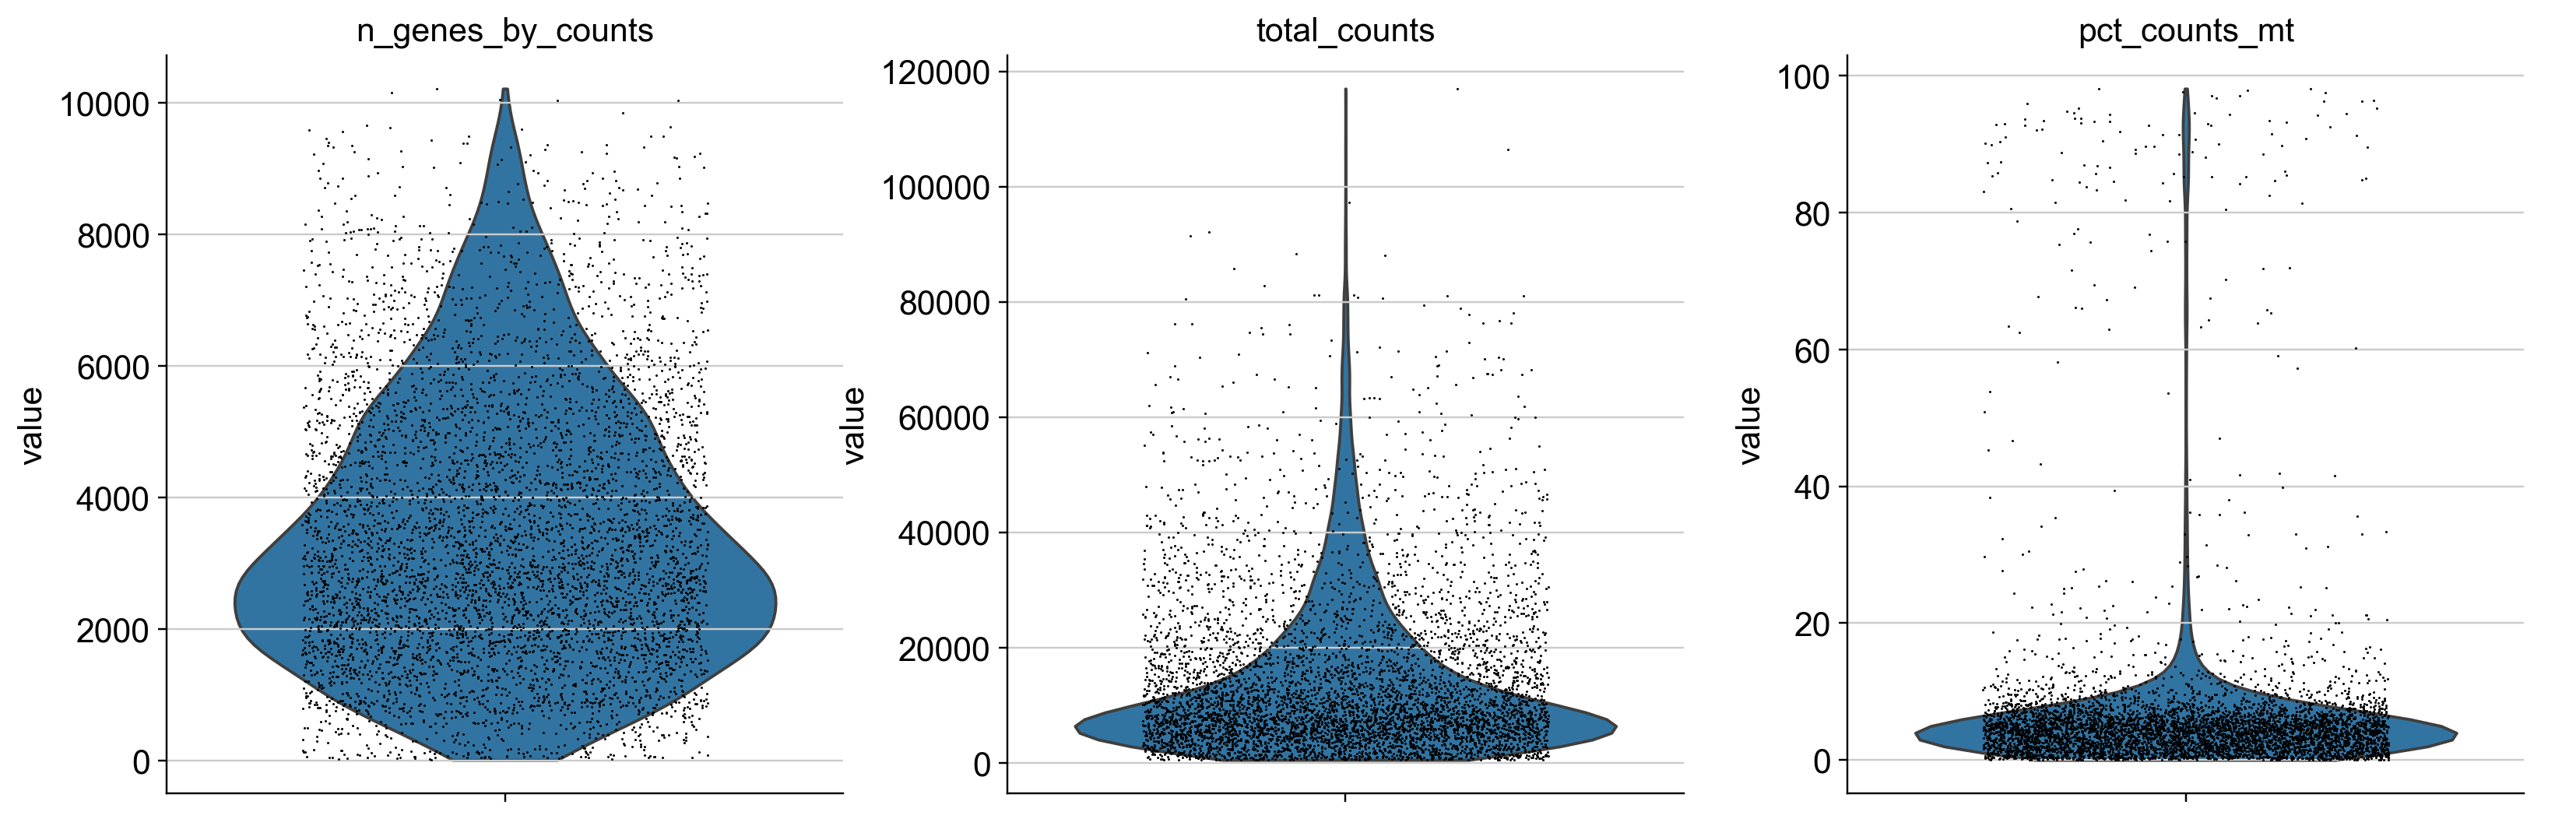

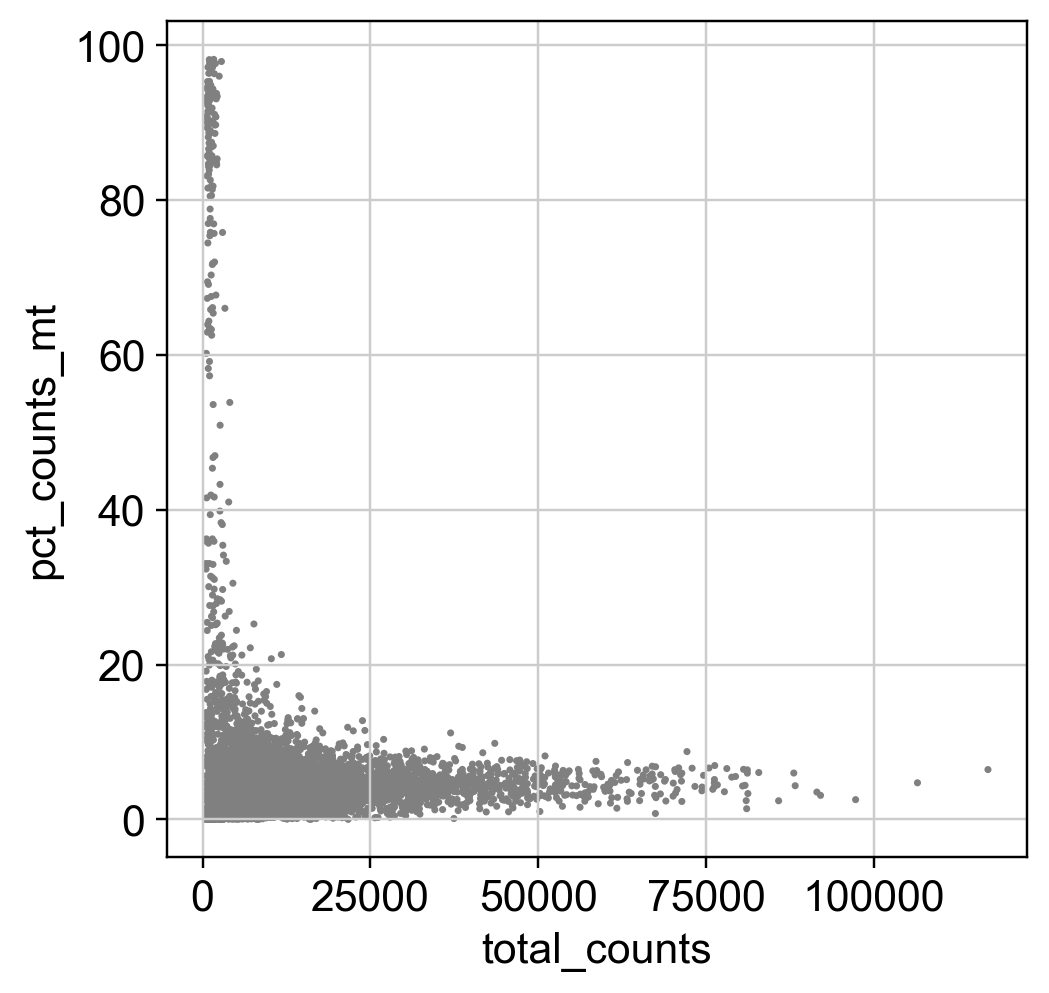

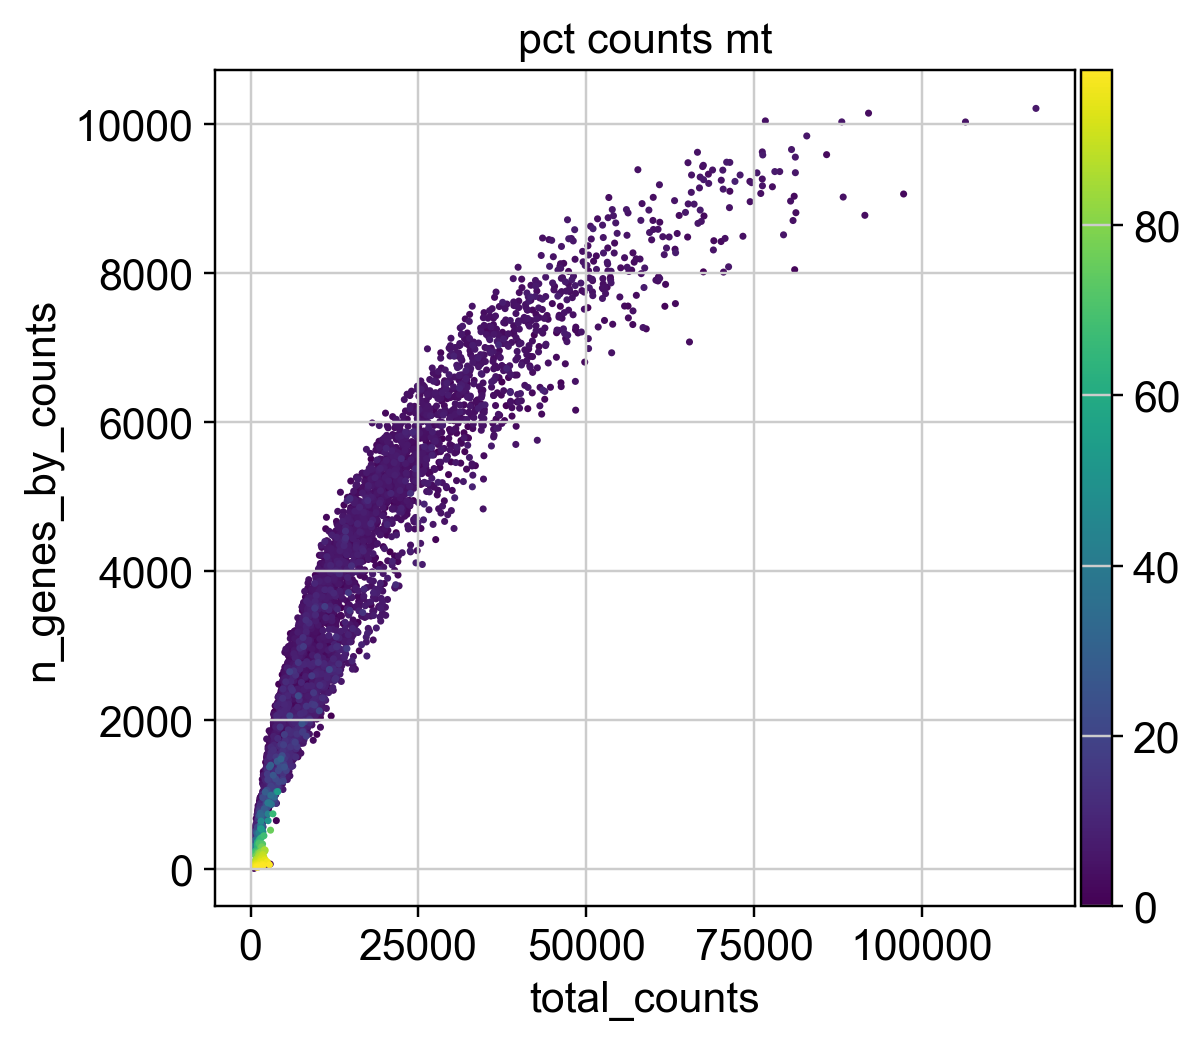

QC distributions — 5v1


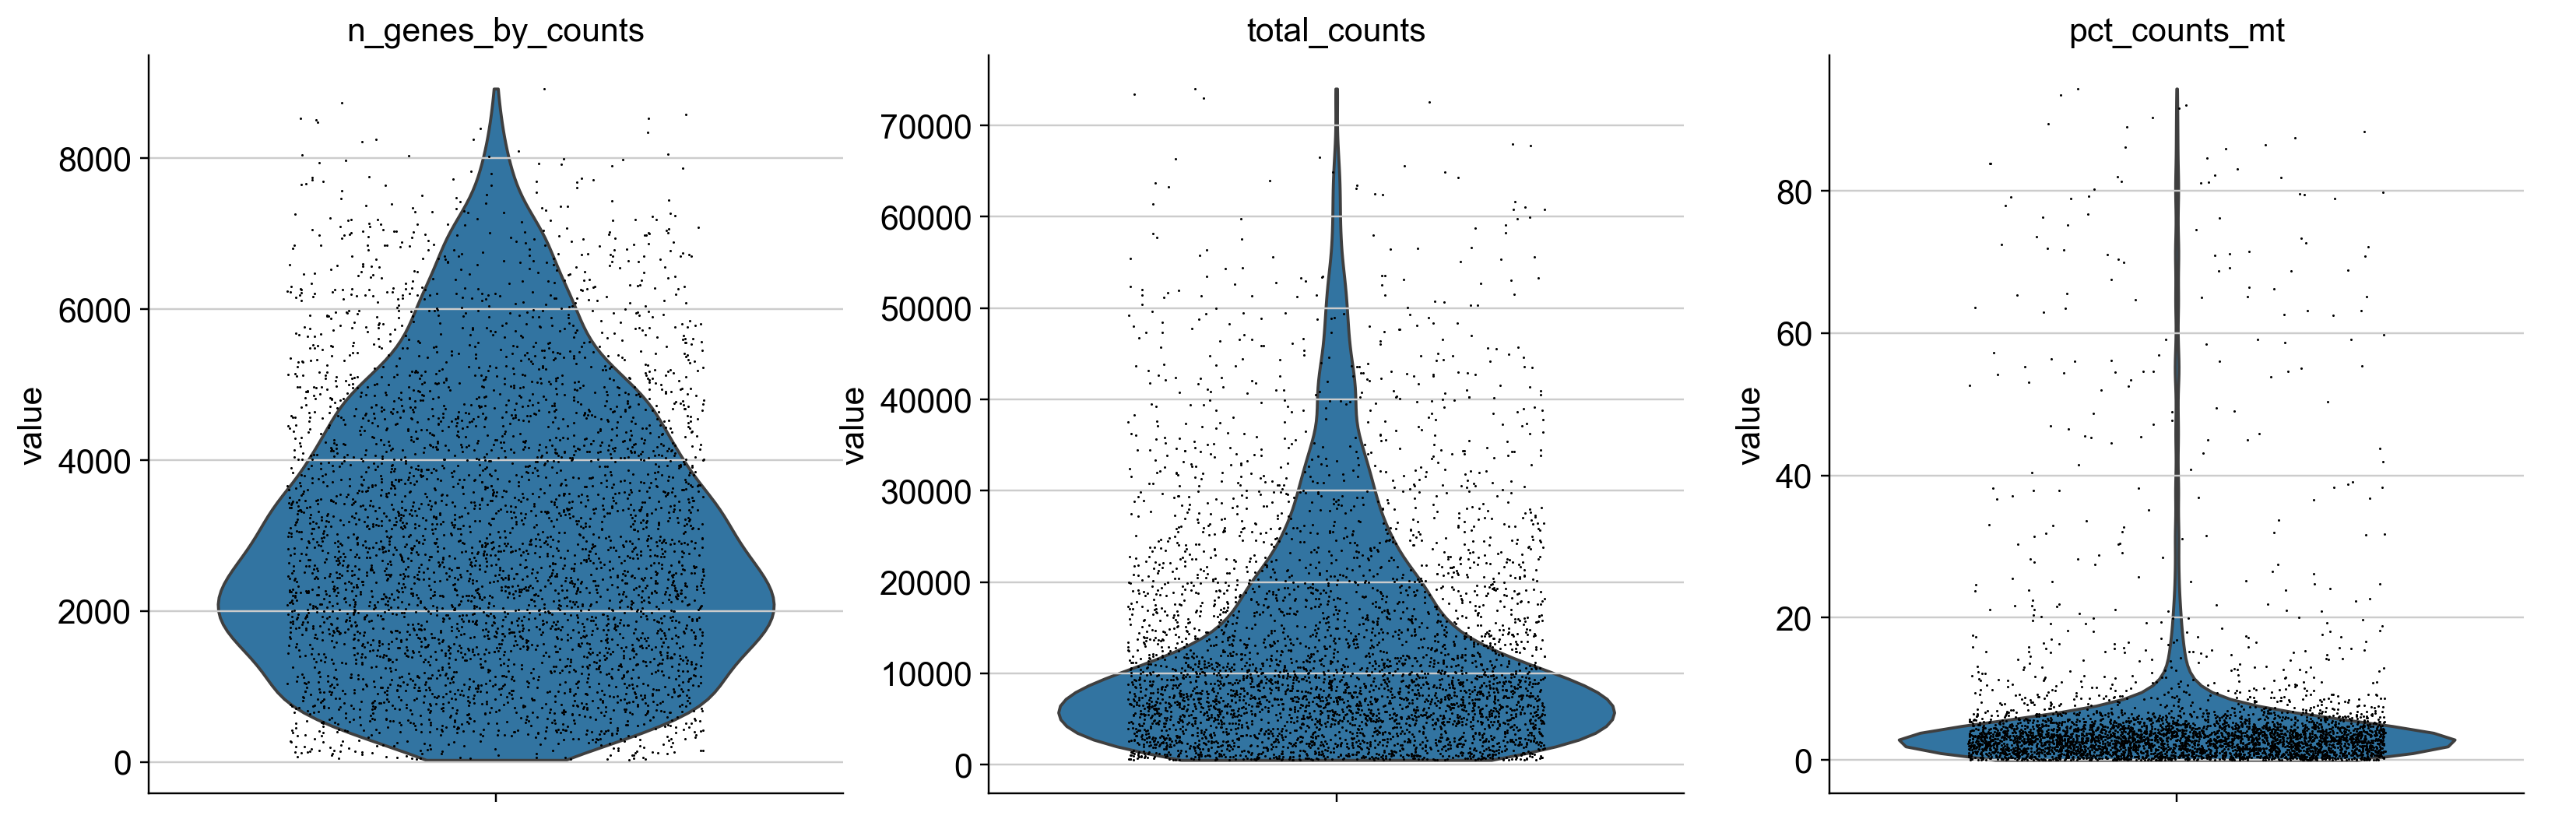

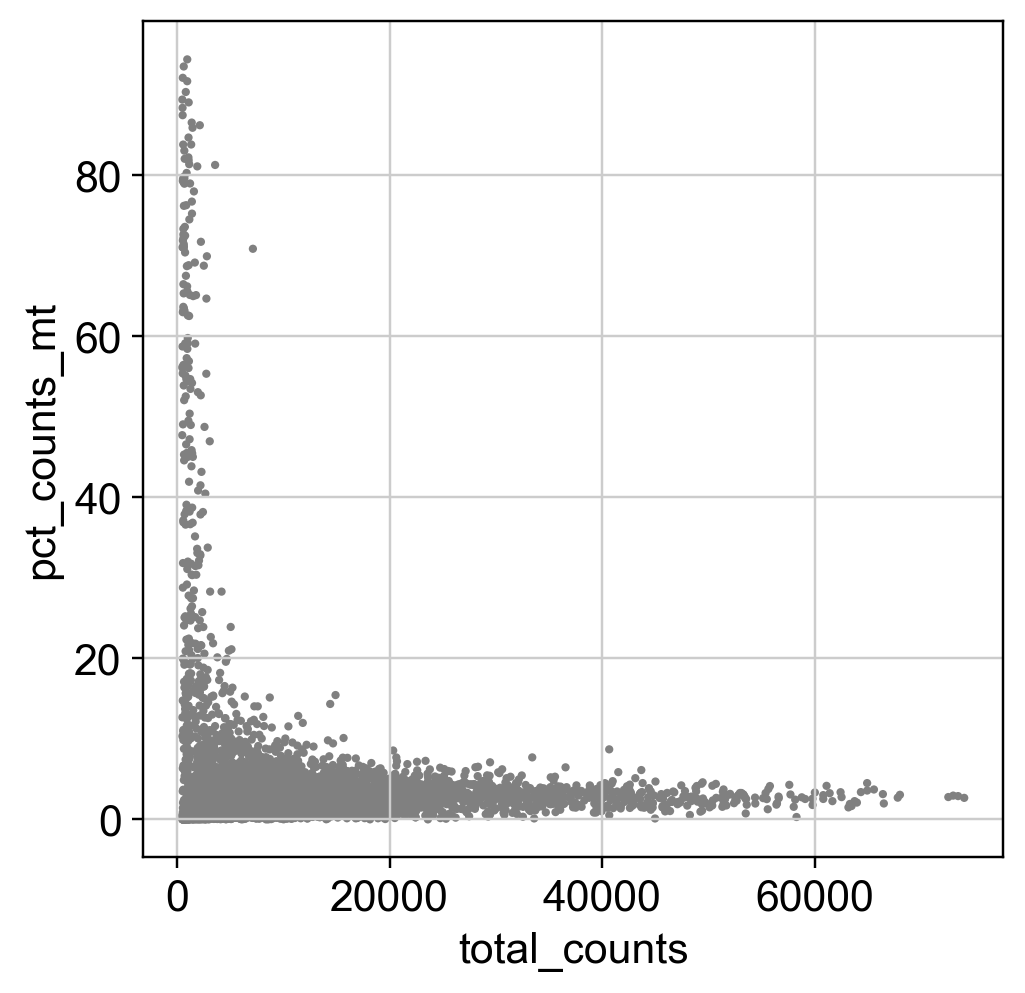

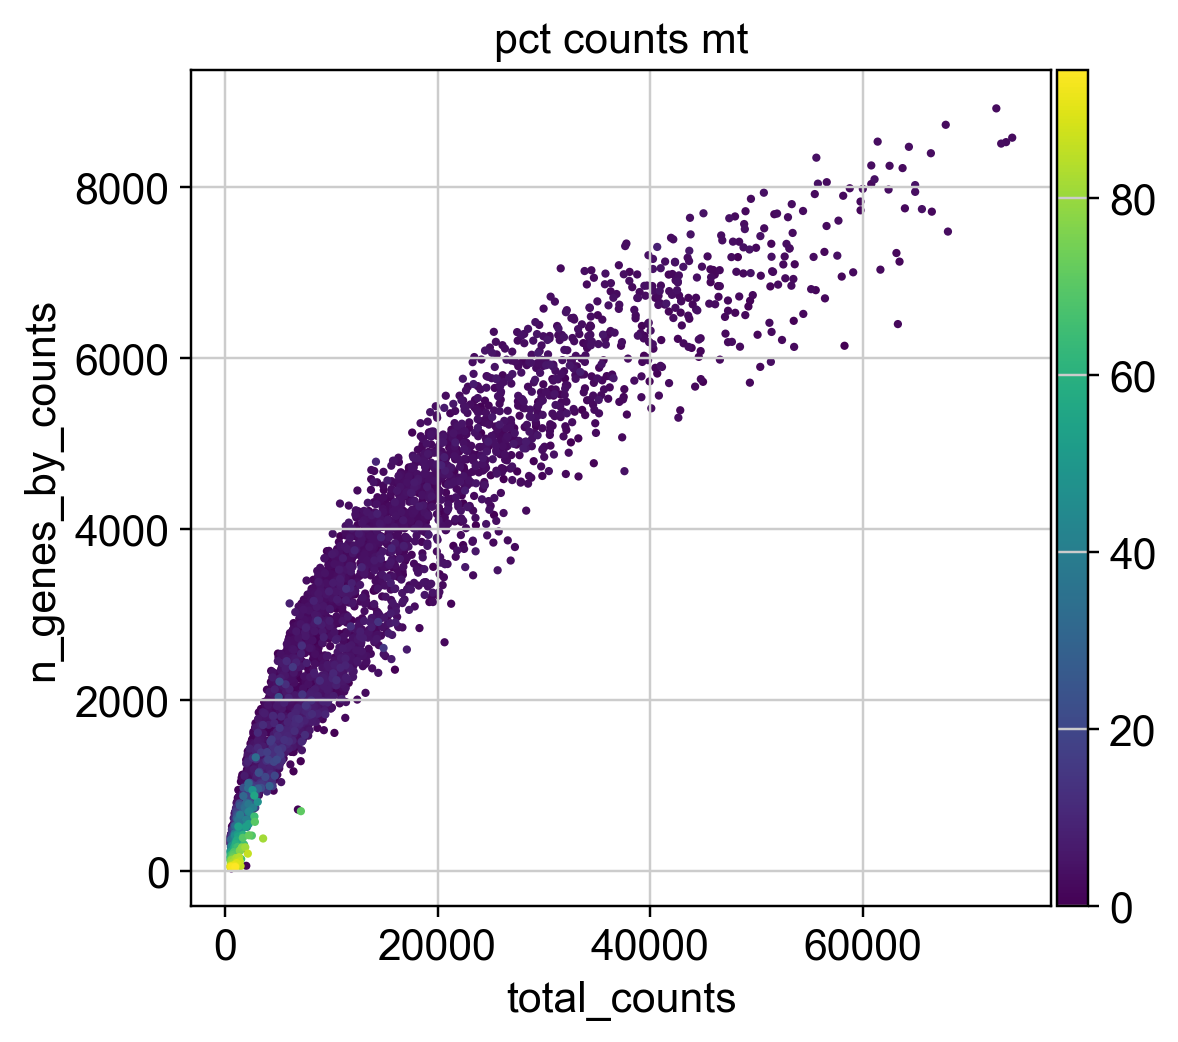

In [36]:
for name, a in adatas.items():
    print(f"QC distributions — {name}")
    sc.pl.violin(
        a,
        keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"],
        jitter=0.3,
        multi_panel=True,
    )
    sc.pl.scatter(a, x="total_counts", y="pct_counts_mt")
    sc.pl.scatter(
    a,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

In [37]:
QC_MIN_GENES = 200       # клетка должна иметь хотя бы 200 детектируемых генов
QC_MAX_GENES = 10000      # верхняя граница — фильтрует возможные дублеты. В обоих датасетах не очень значения не очень большие, так что можно почти не ограничивать
QC_MAX_PCT_MT = 20.0     # доля митохондриальных прочтений, %
QC_MIN_CELLS = 3         # минимальное число клеток, в которых ген детектирован
QC_TOTAL = 60e3         # минимальное число UMI на клетку

def apply_qc_filters(adata: ad.AnnData) -> ad.AnnData:
    before = adata.n_obs
    sc.pp.filter_cells(adata, min_genes=QC_MIN_GENES)
    adata = adata[adata.obs["n_genes_by_counts"] < QC_MAX_GENES].copy()
    adata = adata[adata.obs["pct_counts_mt"] < QC_MAX_PCT_MT].copy()
    adata = adata[adata.obs["total_counts"] < QC_TOTAL].copy()
    sc.pp.filter_genes(adata, min_cells=QC_MIN_CELLS)
    print(f"  клетки: {before} -> {adata.n_obs} | гены: {adata.n_vars}")
    return adata

for name in list(adatas):
    print(f"Filtering {name} ...")
    adatas[name] = apply_qc_filters(adatas[name])

Filtering 3v3 ...
filtered out 98 cells that have less than 200 genes expressed
filtered out 12416 genes that are detected in less than 3 cells
  клетки: 5604 -> 5298 | гены: 24185
Filtering 5v1 ...
filtered out 60 cells that have less than 200 genes expressed
filtered out 14270 genes that are detected in less than 3 cells
  клетки: 4103 -> 3886 | гены: 22331


## Нормализация и логарифм

Сохраним raw counts в `adata.layers["counts"]` — они понадобятся для функции хромосомных средних (она ожидает сырьё на входе).

Дальше канонический шаг scanpy: нормализуем суммарный UMI каждой клетки до `1e4` и применяем `log1p`. Это даст нам адекватное пространство признаков для PCA/UMAP. 

In [39]:
def normalize(adata: ad.AnnData) -> None:
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

for a in adatas.values():
    normalize(a)

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


## Highly-variable genes (HVG), масштабирование, PCA

Берём 2000 HVG. Далее — масштабирование и PCA с использованием только HVG – стандартная практика!

In [40]:
N_HVG = 2000

def feature_selection_and_pca(adata: ad.AnnData) -> None:
    sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor="seurat")
    # Сохраняем log-нормализованные значения в .raw, чтобы потом можно было
    # отрисовывать любой ген без зависимости от scale/subset.
    adata.raw = adata
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

for name, a in adatas.items():
    print(f"PCA for {name} ...")
    feature_selection_and_pca(a)

PCA for 3v3 ...
extracting highly variable genes
    finished (0:00:00)


/opt/homebrew/Caskroom/mambaforge/base/envs/singlecell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50


/opt/homebrew/Caskroom/mambaforge/base/envs/singlecell/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)
PCA for 5v1 ...
extracting highly variable genes
    finished (0:00:00)


/opt/homebrew/Caskroom/mambaforge/base/envs/singlecell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50


/opt/homebrew/Caskroom/mambaforge/base/envs/singlecell/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)


## Граф ближайших соседей, UMAP, кластеры Leiden

`n_neighbors=15` и первые 30 компонент PCA — рабочие значения по умолчанию. `resolution=0.5` даёт большое число кластеров, выбор зависит от задачи, нам лучше поделить посильнее что бы наши раковые кластера с нормальными не обьединились во едино

In [41]:
N_PCS = 30
LEIDEN_RES = 0.5

def embed_and_cluster(adata: ad.AnnData) -> None:
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=N_PCS)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=LEIDEN_RES, flavor="igraph", n_iterations=2, directed=False)

for name, a in adatas.items():
    print(f"Embedding {name} ...")
    embed_and_cluster(a)

Embedding 3v3 ...
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:05)
running Leiden clustering
    finished (0:00:00)
Embedding 5v1 ...
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:04)
running Leiden clustering
    finished (0:00:00)


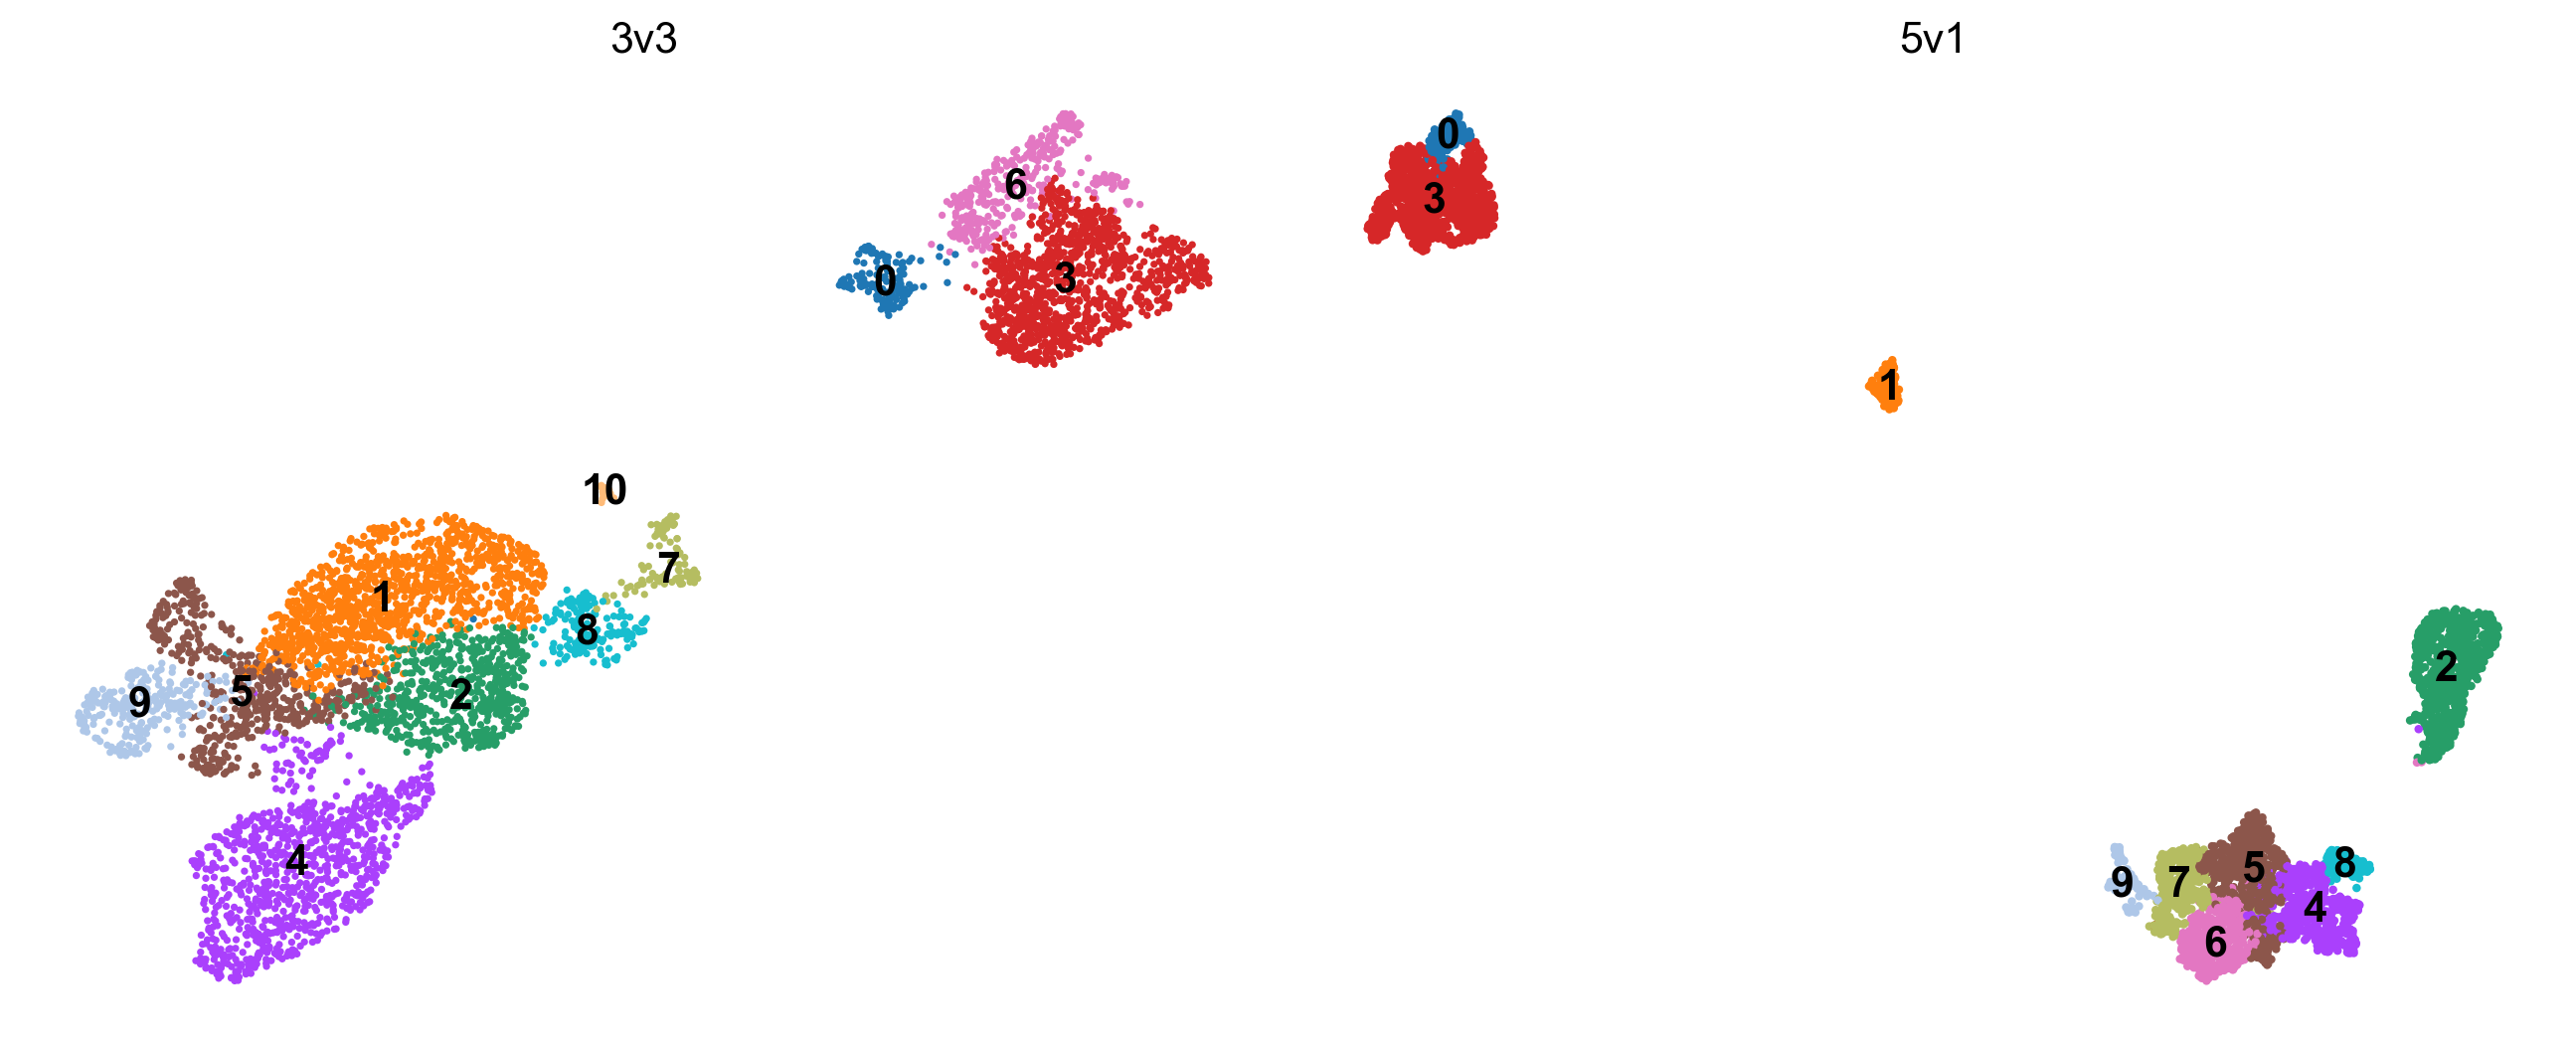

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, a) in zip(axes, adatas.items()):
    sc.pl.umap(a, color="leiden", legend_loc="on data", title=name, ax=ax, show=False)
plt.tight_layout()
plt.show()


=== 3v3 ===
  Tumor: ['PTPRZ1', 'SOX2', 'GPM6A', 'OLIG2', 'MT3']
  Myeloid: ['AIF1', 'C1QA', 'C3', 'HLA-DRA', 'TMEM119']
  T-cells: ['CD3D', 'CD3E', 'CD8A', 'CD4']
  Endothelial: ['PECAM1', 'VWF', 'CLDN5']
  Oligo: ['MOG', 'MBP', 'PLP1']


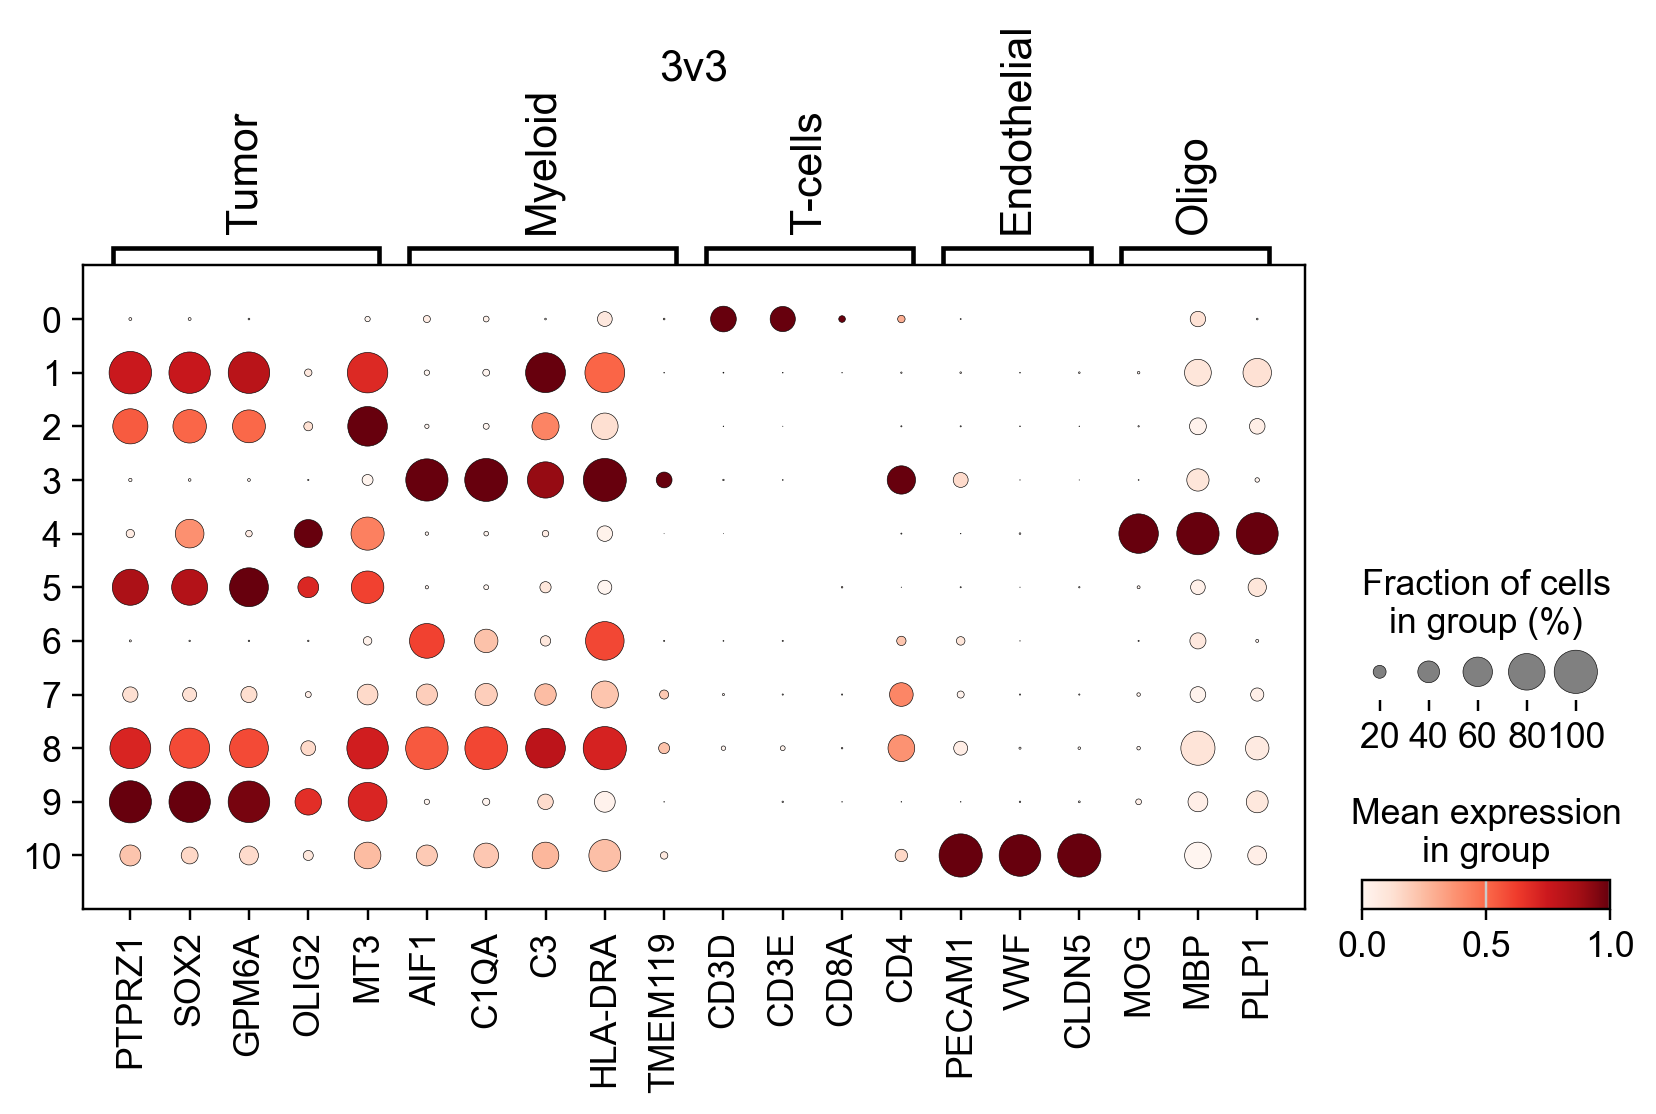


=== 5v1 ===
  Tumor: ['PTPRZ1', 'SOX2', 'GPM6A', 'OLIG2', 'MT3']
  Myeloid: ['AIF1', 'C1QA', 'C3', 'HLA-DRA', 'TMEM119']
  T-cells: ['CD3D', 'CD3E', 'CD8A', 'CD4']
  Endothelial: ['PECAM1', 'VWF', 'CLDN5']
  Oligo: ['MOG', 'MBP', 'PLP1']


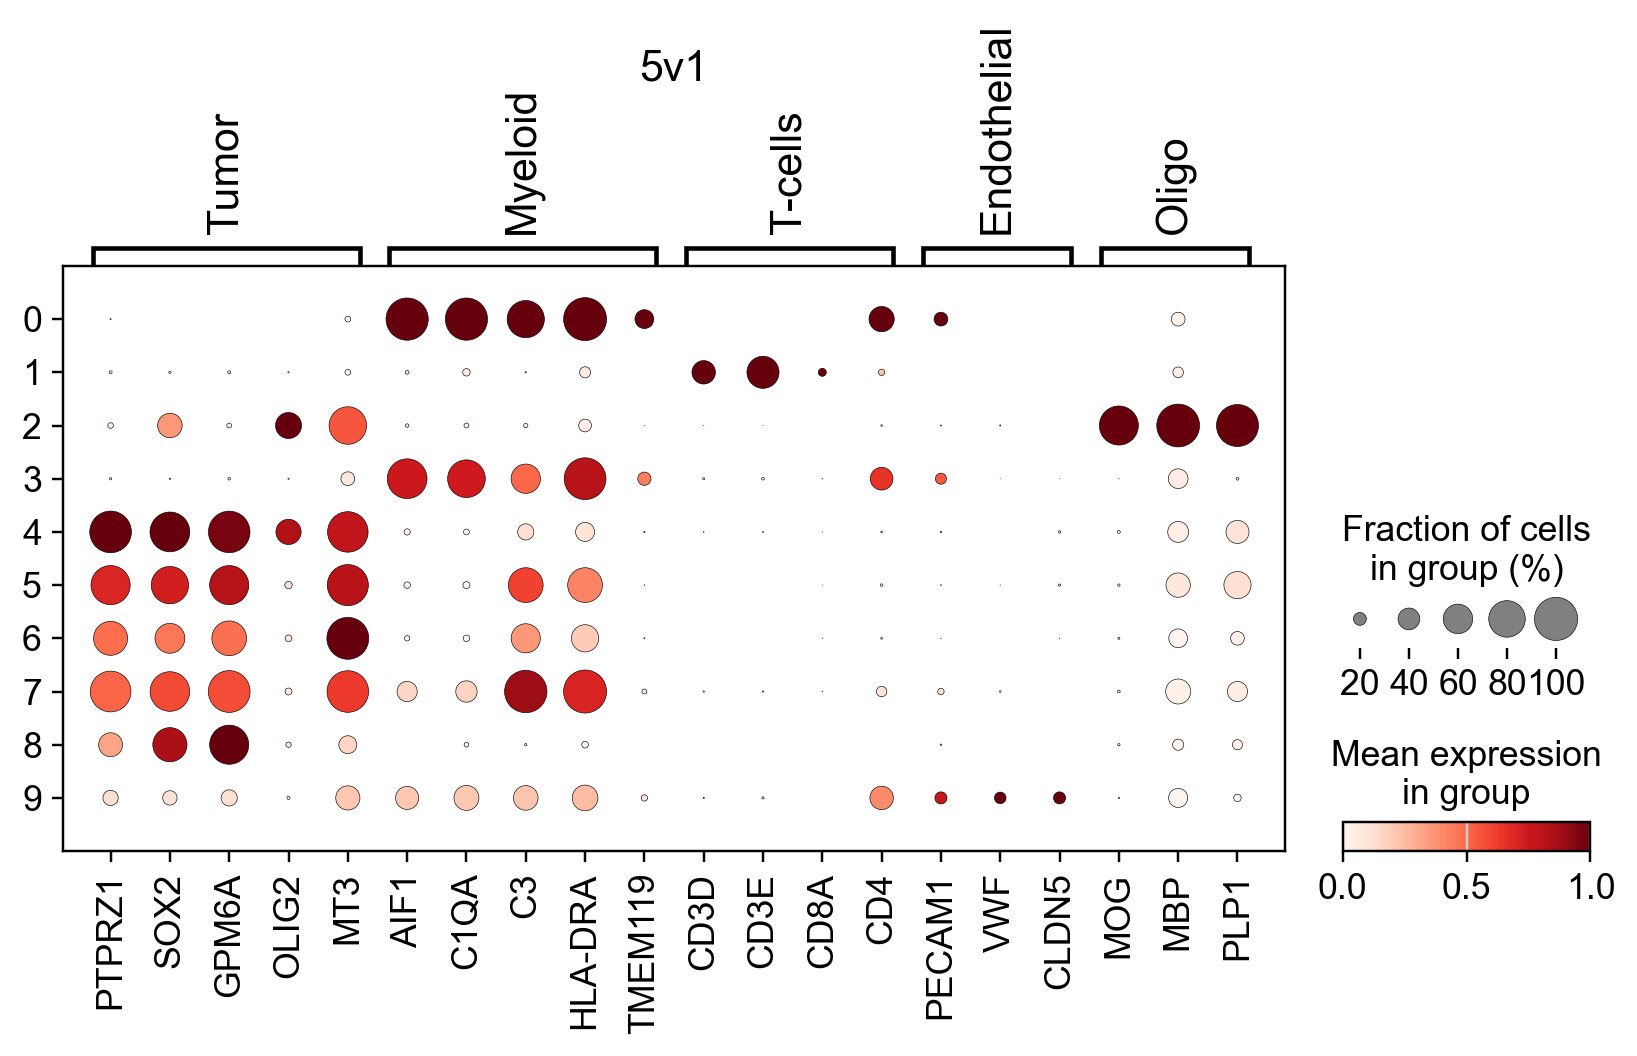

In [43]:
MARKER_PANEL = {
    "Tumor": ["PTPRZ1", "SOX2", "GPM6A", "OLIG2", "MT3"],
    "Myeloid":     ["AIF1", "C1QA", "C3", "HLA-DRA", "TMEM119"],
    "T-cells":     ["CD3D", "CD3E", "CD8A", "CD4"],
    "Endothelial": ["PECAM1", "VWF", "CLDN5"],
    "Oligo":       ["MOG", "MBP", "PLP1"]
}

def available_markers(adata: ad.AnnData) -> dict[str, list[str]]:
    present = set(adata.var_names)
    return {group: [g for g in genes if g in present] for group, genes in MARKER_PANEL.items()}

for name, a in adatas.items():
    print(f"\n=== {name} ===")
    panel = available_markers(a)
    for group, genes in panel.items():
        print(f"  {group}: {genes}")
    sc.pl.dotplot(a, panel, groupby="leiden", standard_scale="var", title=name)

### Хромосомные средние — карта активности хромосом по кластерам

До ручной разметки полезно посмотреть, в каких leiden-кластерах какие хромосомы
выражены сильнее. Считаем 22 средние log-нормализованных экспрессий по автосомам
функцией `get_chromosome_means_v2`, кладём результат в
`obs['Chr1..22']` и `obsm['chrom_means']`. Дальше — UMAP-overlay для Chr7 (gain) /
Chr10 (loss) и хитмап `leiden × chromosome`: по нему обычно сразу видно, какие
кластеры выглядят «опухолевыми» по хромосомному сигналу.

In [44]:
import sys
sys.path.insert(0, str(ROOT))
from chromosome_means import get_chromosome_means_v2

def adata_from_counts(adata: ad.AnnData) -> ad.AnnData:
    return ad.AnnData(
        X=adata.layers["counts"],
        obs=adata.obs[[]].copy(),
        var=adata.var[[]].copy(),
    )

chrom_means: dict[str, pd.DataFrame] = {}
for name, a in adatas.items():
    print(f"\n--- {name} ---")
    raw = adata_from_counts(a)
    chrom_means[name] = get_chromosome_means_v2(raw, str(GENE_MAP_CSV), verbose=True)
    df = chrom_means[name].loc[a.obs_names]
    a.obsm["chrom_means"] = df.values
    a.uns["chrom_means_cols"] = list(df.columns)
    for col in df.columns:
        a.obs[col] = df[col].values


--- 3v3 ---
Chromosome 1: mapped 812 genes
Chromosome 2: mapped 553 genes
Chromosome 3: mapped 474 genes
Chromosome 4: mapped 292 genes
Chromosome 5: mapped 382 genes
Chromosome 6: mapped 382 genes
Chromosome 7: mapped 438 genes
Chromosome 8: mapped 297 genes
Chromosome 9: mapped 304 genes
Chromosome 10: mapped 249 genes
Chromosome 11: mapped 494 genes
Chromosome 12: mapped 426 genes
Chromosome 13: mapped 147 genes
Chromosome 14: mapped 282 genes
Chromosome 15: mapped 229 genes
Chromosome 16: mapped 358 genes
Chromosome 17: mapped 464 genes
Chromosome 18: mapped 115 genes
Chromosome 19: mapped 575 genes
Chromosome 20: mapped 209 genes
Chromosome 21: mapped 84 genes
Chromosome 22: mapped 188 genes

--- 5v1 ---
Chromosome 1: mapped 624 genes
Chromosome 2: mapped 415 genes
Chromosome 3: mapped 341 genes
Chromosome 4: mapped 208 genes
Chromosome 5: mapped 276 genes
Chromosome 6: mapped 281 genes
Chromosome 7: mapped 327 genes
Chromosome 8: mapped 205 genes
Chromosome 9: mapped 213 genes
C

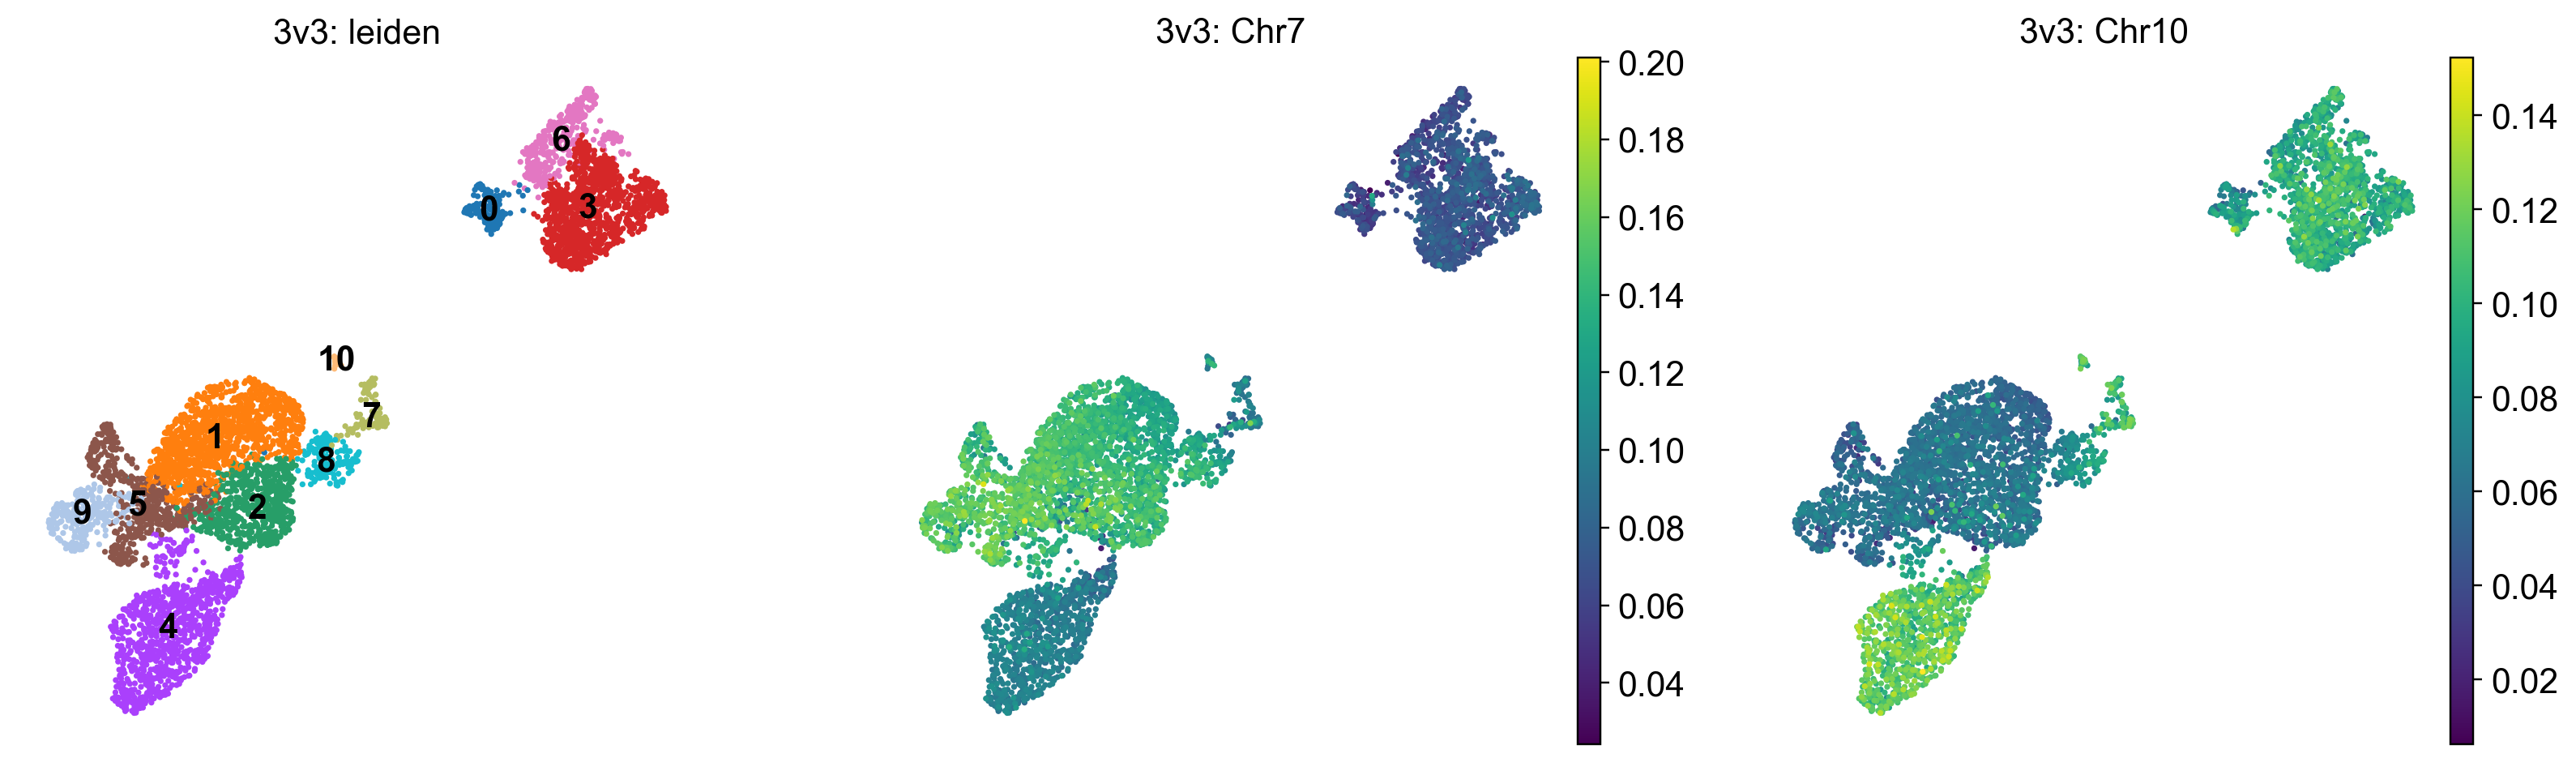

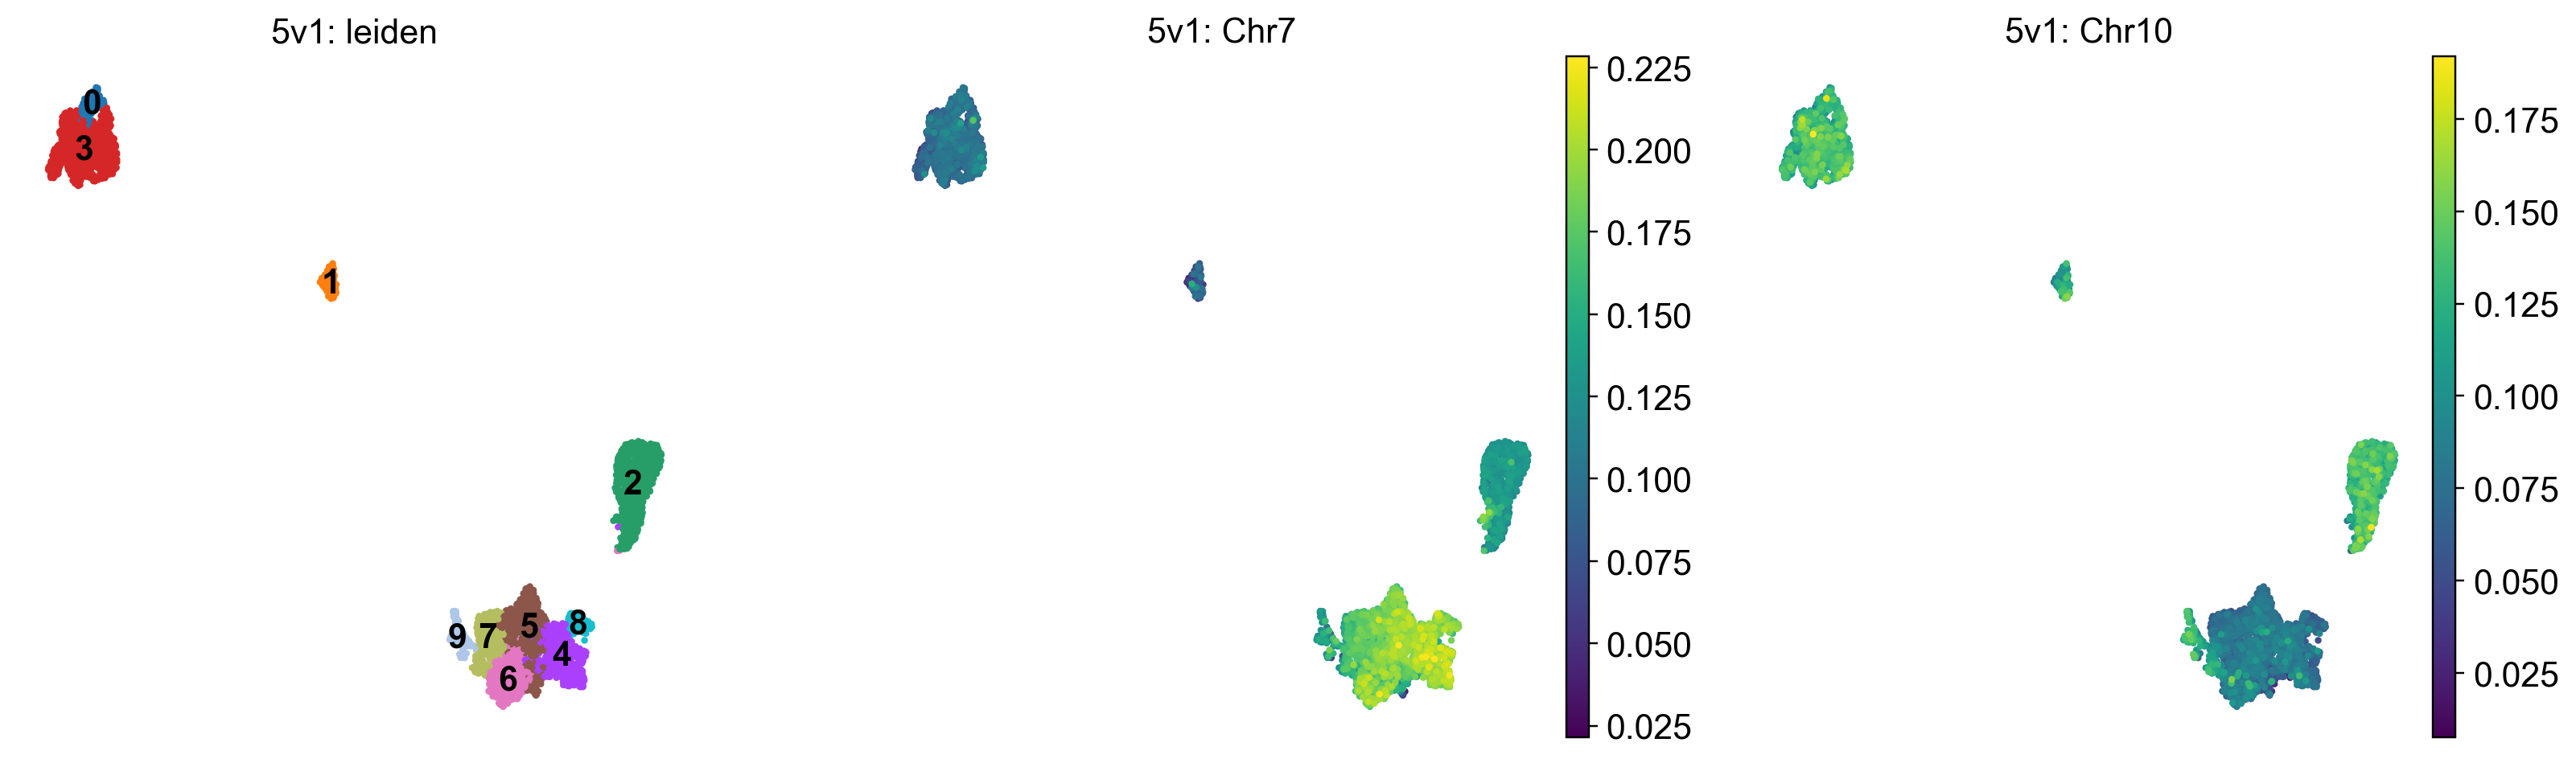

In [45]:
# UMAP-overlay: Chr7 (gain) и Chr10 (loss) — классическая сигнатура глиобластомы.
GBM_HALLMARK_CHROMS = ["Chr7", "Chr10"]
for name, a in adatas.items():
    sc.pl.umap(
        a,
        color=["leiden", *GBM_HALLMARK_CHROMS],
        ncols=3,
        legend_loc="on data",
        cmap="viridis",
        title=[f"{name}: leiden"] + [f"{name}: {c}" for c in GBM_HALLMARK_CHROMS],
    )

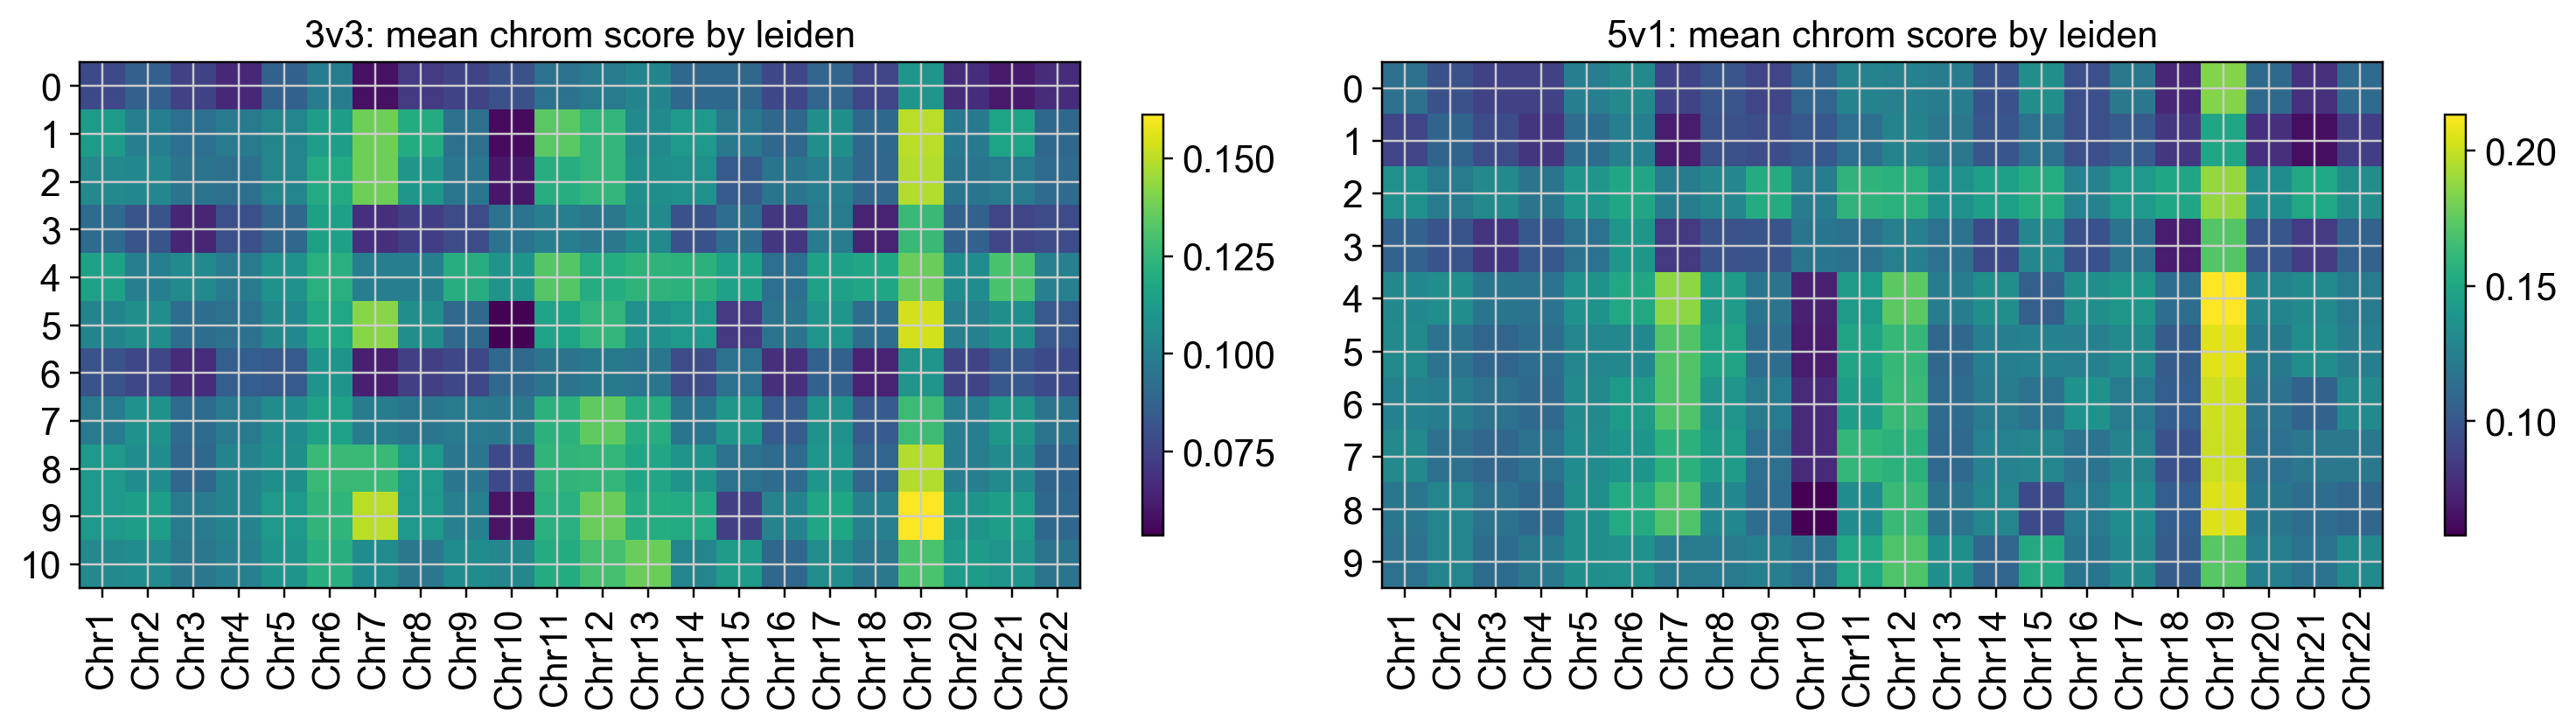

In [46]:
# Хитмап средних хромосомных значений по кластерам — карта «где что активно».
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, a) in zip(axes, adatas.items()):
    chrom_cols = a.uns["chrom_means_cols"]
    by_cluster = a.obs.groupby("leiden", observed=True)[chrom_cols].mean()
    im = ax.imshow(by_cluster.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(chrom_cols)))
    ax.set_xticklabels(chrom_cols, rotation=90)
    ax.set_yticks(range(len(by_cluster.index)))
    ax.set_yticklabels(by_cluster.index)
    ax.set_title(f"{name}: mean chrom score by leiden")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

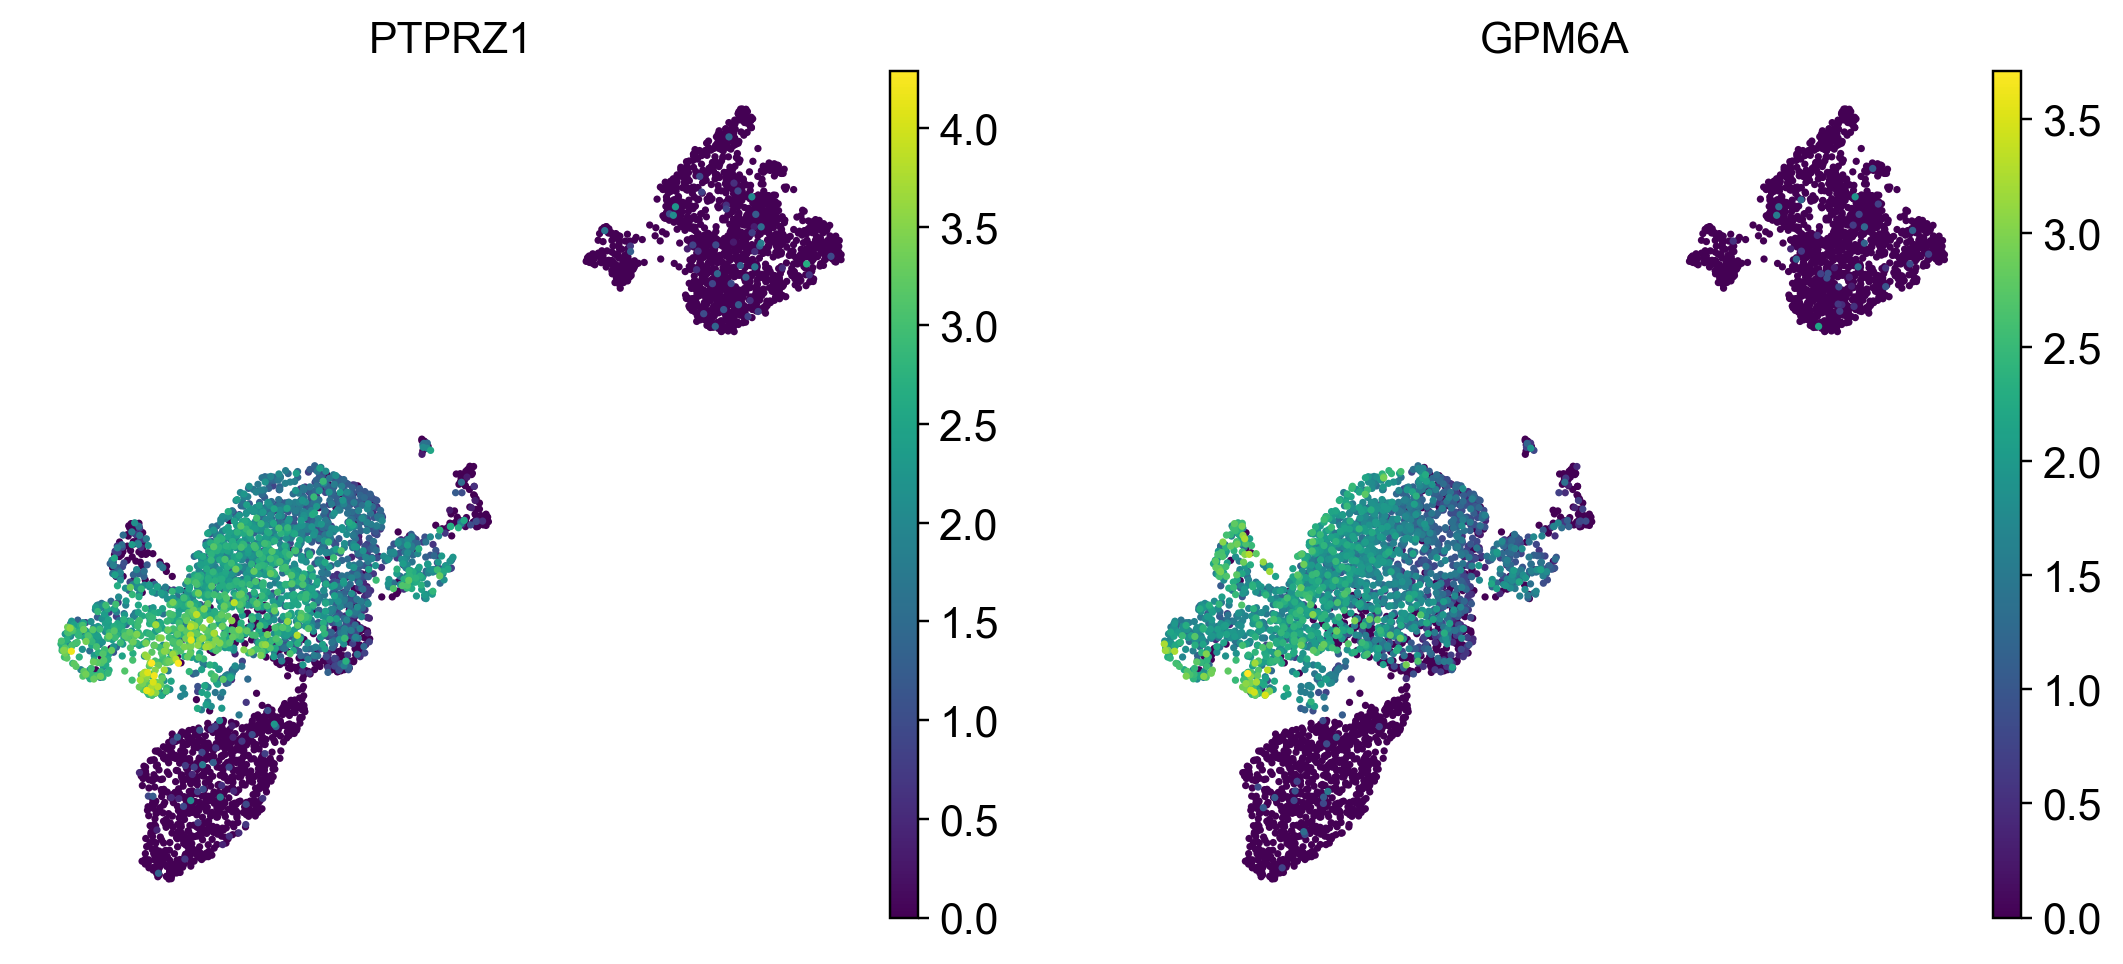

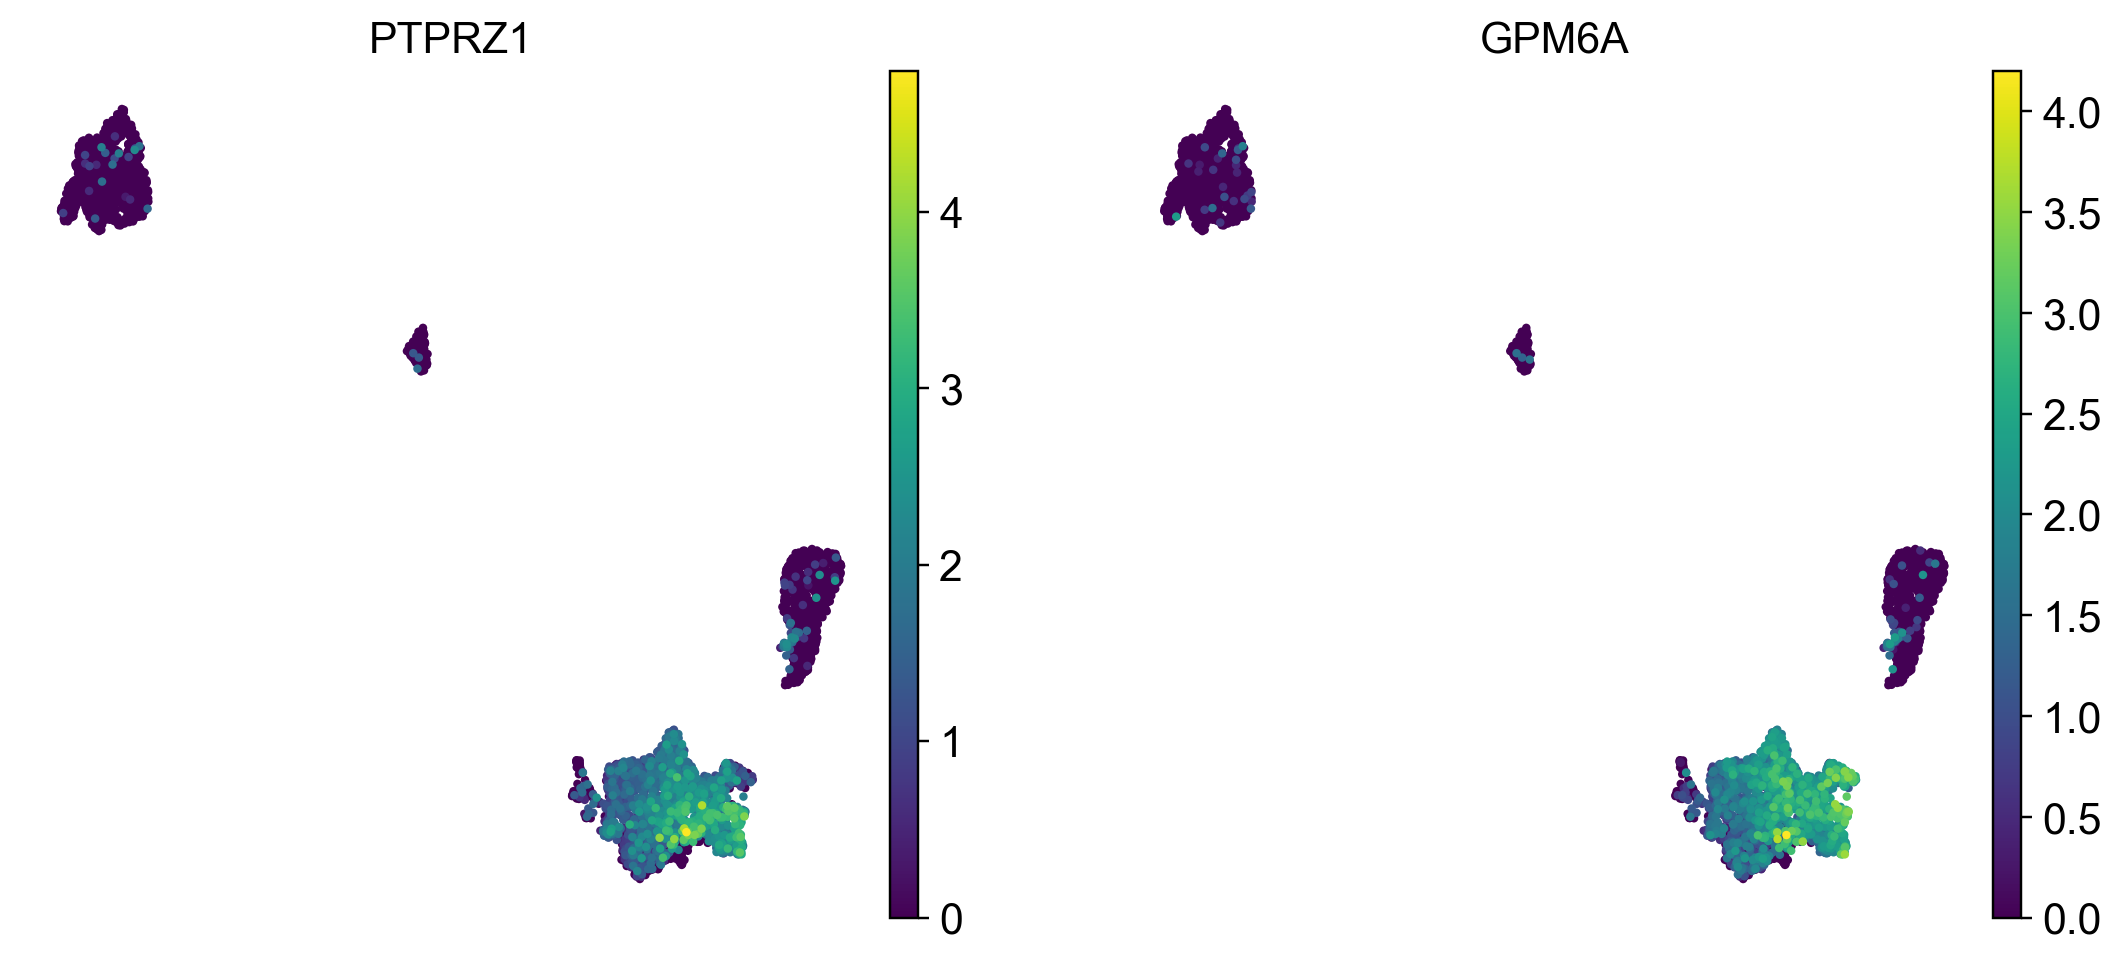

In [162]:
from matplotlib import cm
for name, a in adatas.items():
    sc.pl.umap(a, color=['PTPRZ1', 'GPM6A'], ncols=2, show=False, cmap=cm.viridis)

# Rename clusters

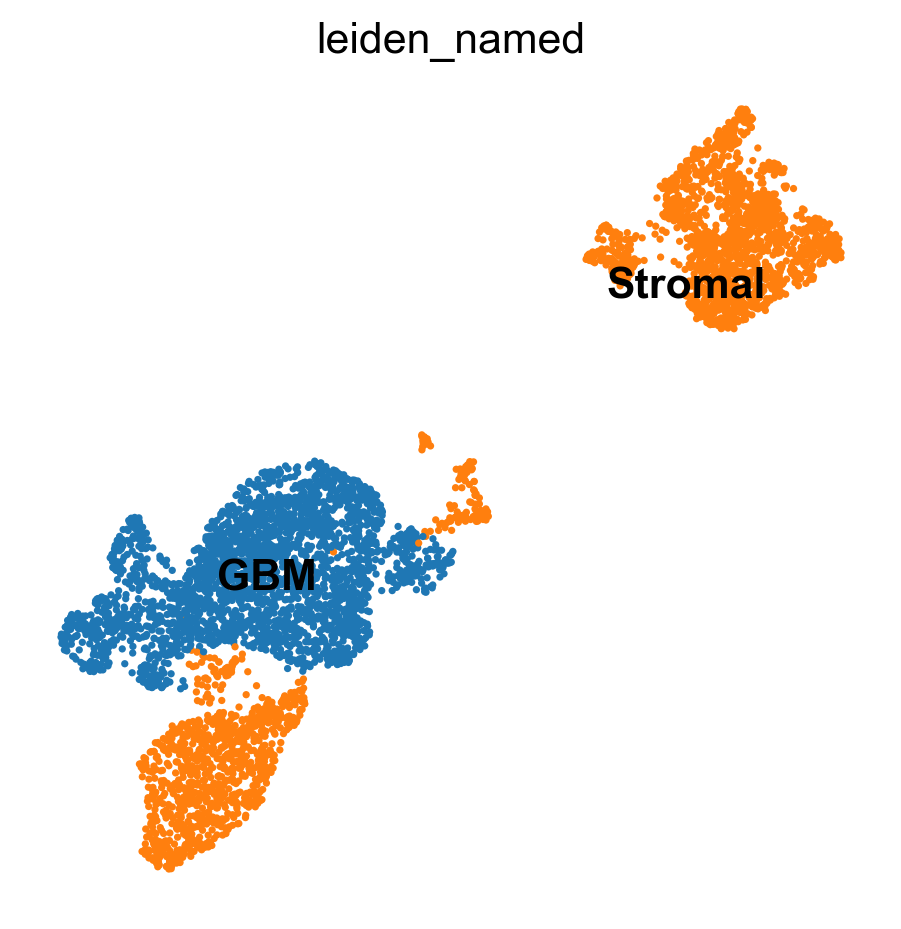

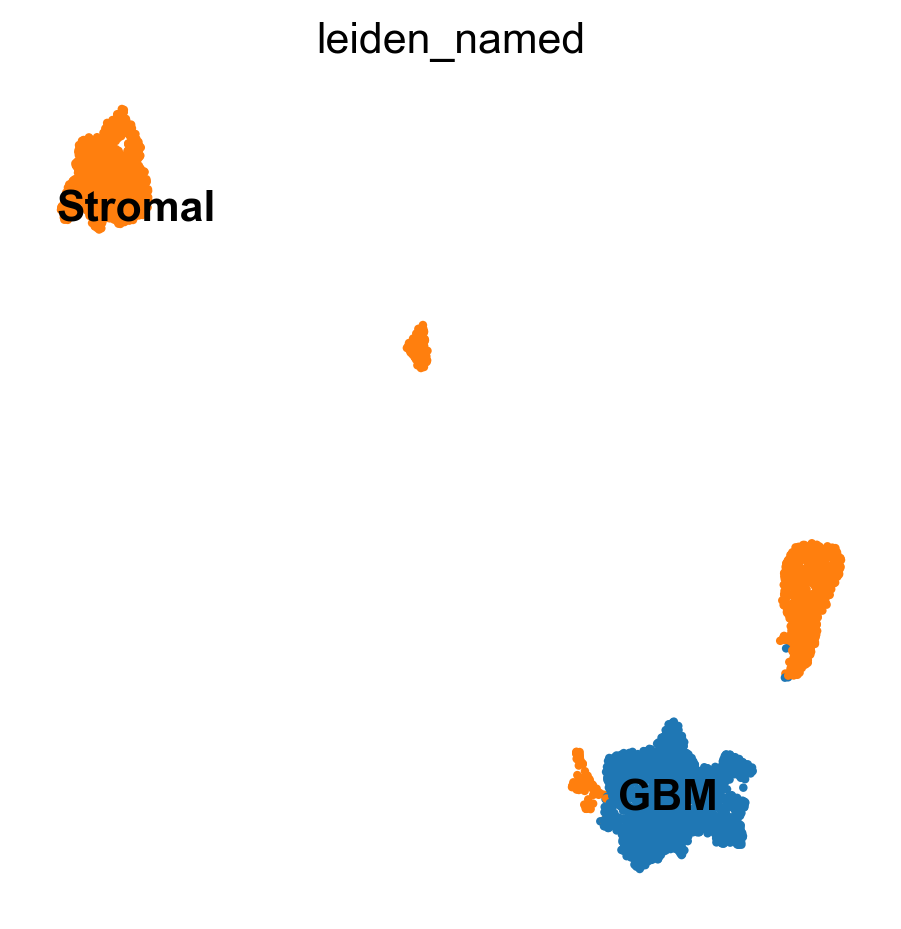

In [47]:
mapping0 = {
    "1": "GBM",
    "2": "GBM",
    "5": "GBM",
    "8": "GBM",
    "9": "GBM",

    "0": "Stromal",
    "3": "Stromal",
    "4": "Stromal",
    "6": "Stromal",
    "7": "Stromal",
    "10": "Stromal"
}

adatas['3v3'].obs["leiden_named"] = adatas['3v3'].obs["leiden"].astype(str).map(mapping0)


mapping1 = {
    "4": "GBM",
    "5": "GBM",
    "6": "GBM",
    "7": "GBM",
    "8": "GBM",

    "0": "Stromal",
    "1": "Stromal",
    "2": "Stromal",
    "3": "Stromal",
    "9": "Stromal",
}

adatas['5v1'].obs["leiden_named"] = adatas['5v1'].obs["leiden"].astype(str).map(mapping1)


for name, a in adatas.items():
    sc.pl.umap(
        a,
        color="leiden_named",
        legend_loc="on data"
    )

## Хромосомные средние как признаки (feature engeneering)

Размечен `obs['leiden_named']` со значениями `GBM` / `Stromal`. Теперь готовим
числовое представление для классификатора: на каждую клетку — 22 признака,
среднее `log2(CPM/10 + 1)` по генам каждой автосомы. Делает это уже знакомая
функция `get_chromosome_means_v2`. Подаём ей **сырые counts** из
`adata.layers['counts']`, чтобы внутренняя нормализация была идентична
оригинальному R-скрипту.

In [48]:
import sys
sys.path.insert(0, str(ROOT))
from chromosome_means import get_chromosome_means_v2

CHR_COLS = [f"Chr{i}" for i in range(1, 23)]

def build_feature_table(adata: ad.AnnData) -> pd.DataFrame:
    raw = ad.AnnData(
        X=adata.layers["counts"],
        obs=adata.obs[[]].copy(),
        var=adata.var[[]].copy(),
    )
    chrom_df = get_chromosome_means_v2(raw, str(GENE_MAP_CSV), verbose=False)
    chrom_df = chrom_df[CHR_COLS]
    chrom_df["label"] = adata.obs["leiden_named"].astype(str).values
    return chrom_df

tables = {name: build_feature_table(a) for name, a in adatas.items()}

for name, t in tables.items():
    print(f"\n{name}: {t.shape[0]} клеток, {t.shape[1] - 1} признаков")
    print(t["label"].value_counts())
    print(t.head())


3v3: 5298 клеток, 22 признаков
label
GBM        2688
Stromal    2610
Name: count, dtype: int64
                            Chr1      Chr2      Chr3      Chr4      Chr5  \
3v3-AAACCCAAGGCGATAC-1  0.071730  0.066975  0.070435  0.055272  0.083253   
3v3-AAACCCACAAGTCCCG-1  0.121523  0.116314  0.098805  0.105763  0.107043   
3v3-AAACCCACAGATGCGA-1  0.096251  0.076909  0.059370  0.082231  0.104007   
3v3-AAACCCACAGGTGAGT-1  0.114286  0.101868  0.107254  0.117359  0.107198   
3v3-AAACCCAGTCTTGCGG-1  0.103565  0.118353  0.094400  0.092661  0.107593   

                            Chr6      Chr7      Chr8      Chr9     Chr10  ...  \
3v3-AAACCCAAGGCGATAC-1  0.087482  0.037789  0.068853  0.070001  0.045940  ...   
3v3-AAACCCACAAGTCCCG-1  0.111982  0.144742  0.128953  0.103422  0.059278  ...   
3v3-AAACCCACAGATGCGA-1  0.108988  0.063746  0.094748  0.082236  0.124512  ...   
3v3-AAACCCACAGGTGAGT-1  0.124604  0.107298  0.111049  0.129169  0.108257  ...   
3v3-AAACCCAGTCTTGCGG-1  0.128229  0.158682

## Распределения Chr7 / Chr10 и корреляции

Классическая сигнатура глиобластомы — *gain* хромосомы 7 и *loss* хромосомы 10.
Проверяем визуально, что наша разметка согласуется с этим биологическим ожиданием.
Заодно строим корреляции всех признаков с классом и между собой.

In [49]:
tables['3v3'].sum()

Chr1                                            546.796631
Chr2                                            511.760529
Chr3                                            463.681244
Chr4                                            488.206726
Chr5                                            530.019165
Chr6                                            617.200073
Chr7                                            580.542847
Chr8                                            525.663696
Chr9                                            497.679504
Chr10                                            414.73761
Chr11                                           628.256775
Chr12                                           616.153442
Chr13                                           580.477661
Chr14                                           550.400574
Chr15                                           498.472046
Chr16                                           457.465393
Chr17                                           555.6873

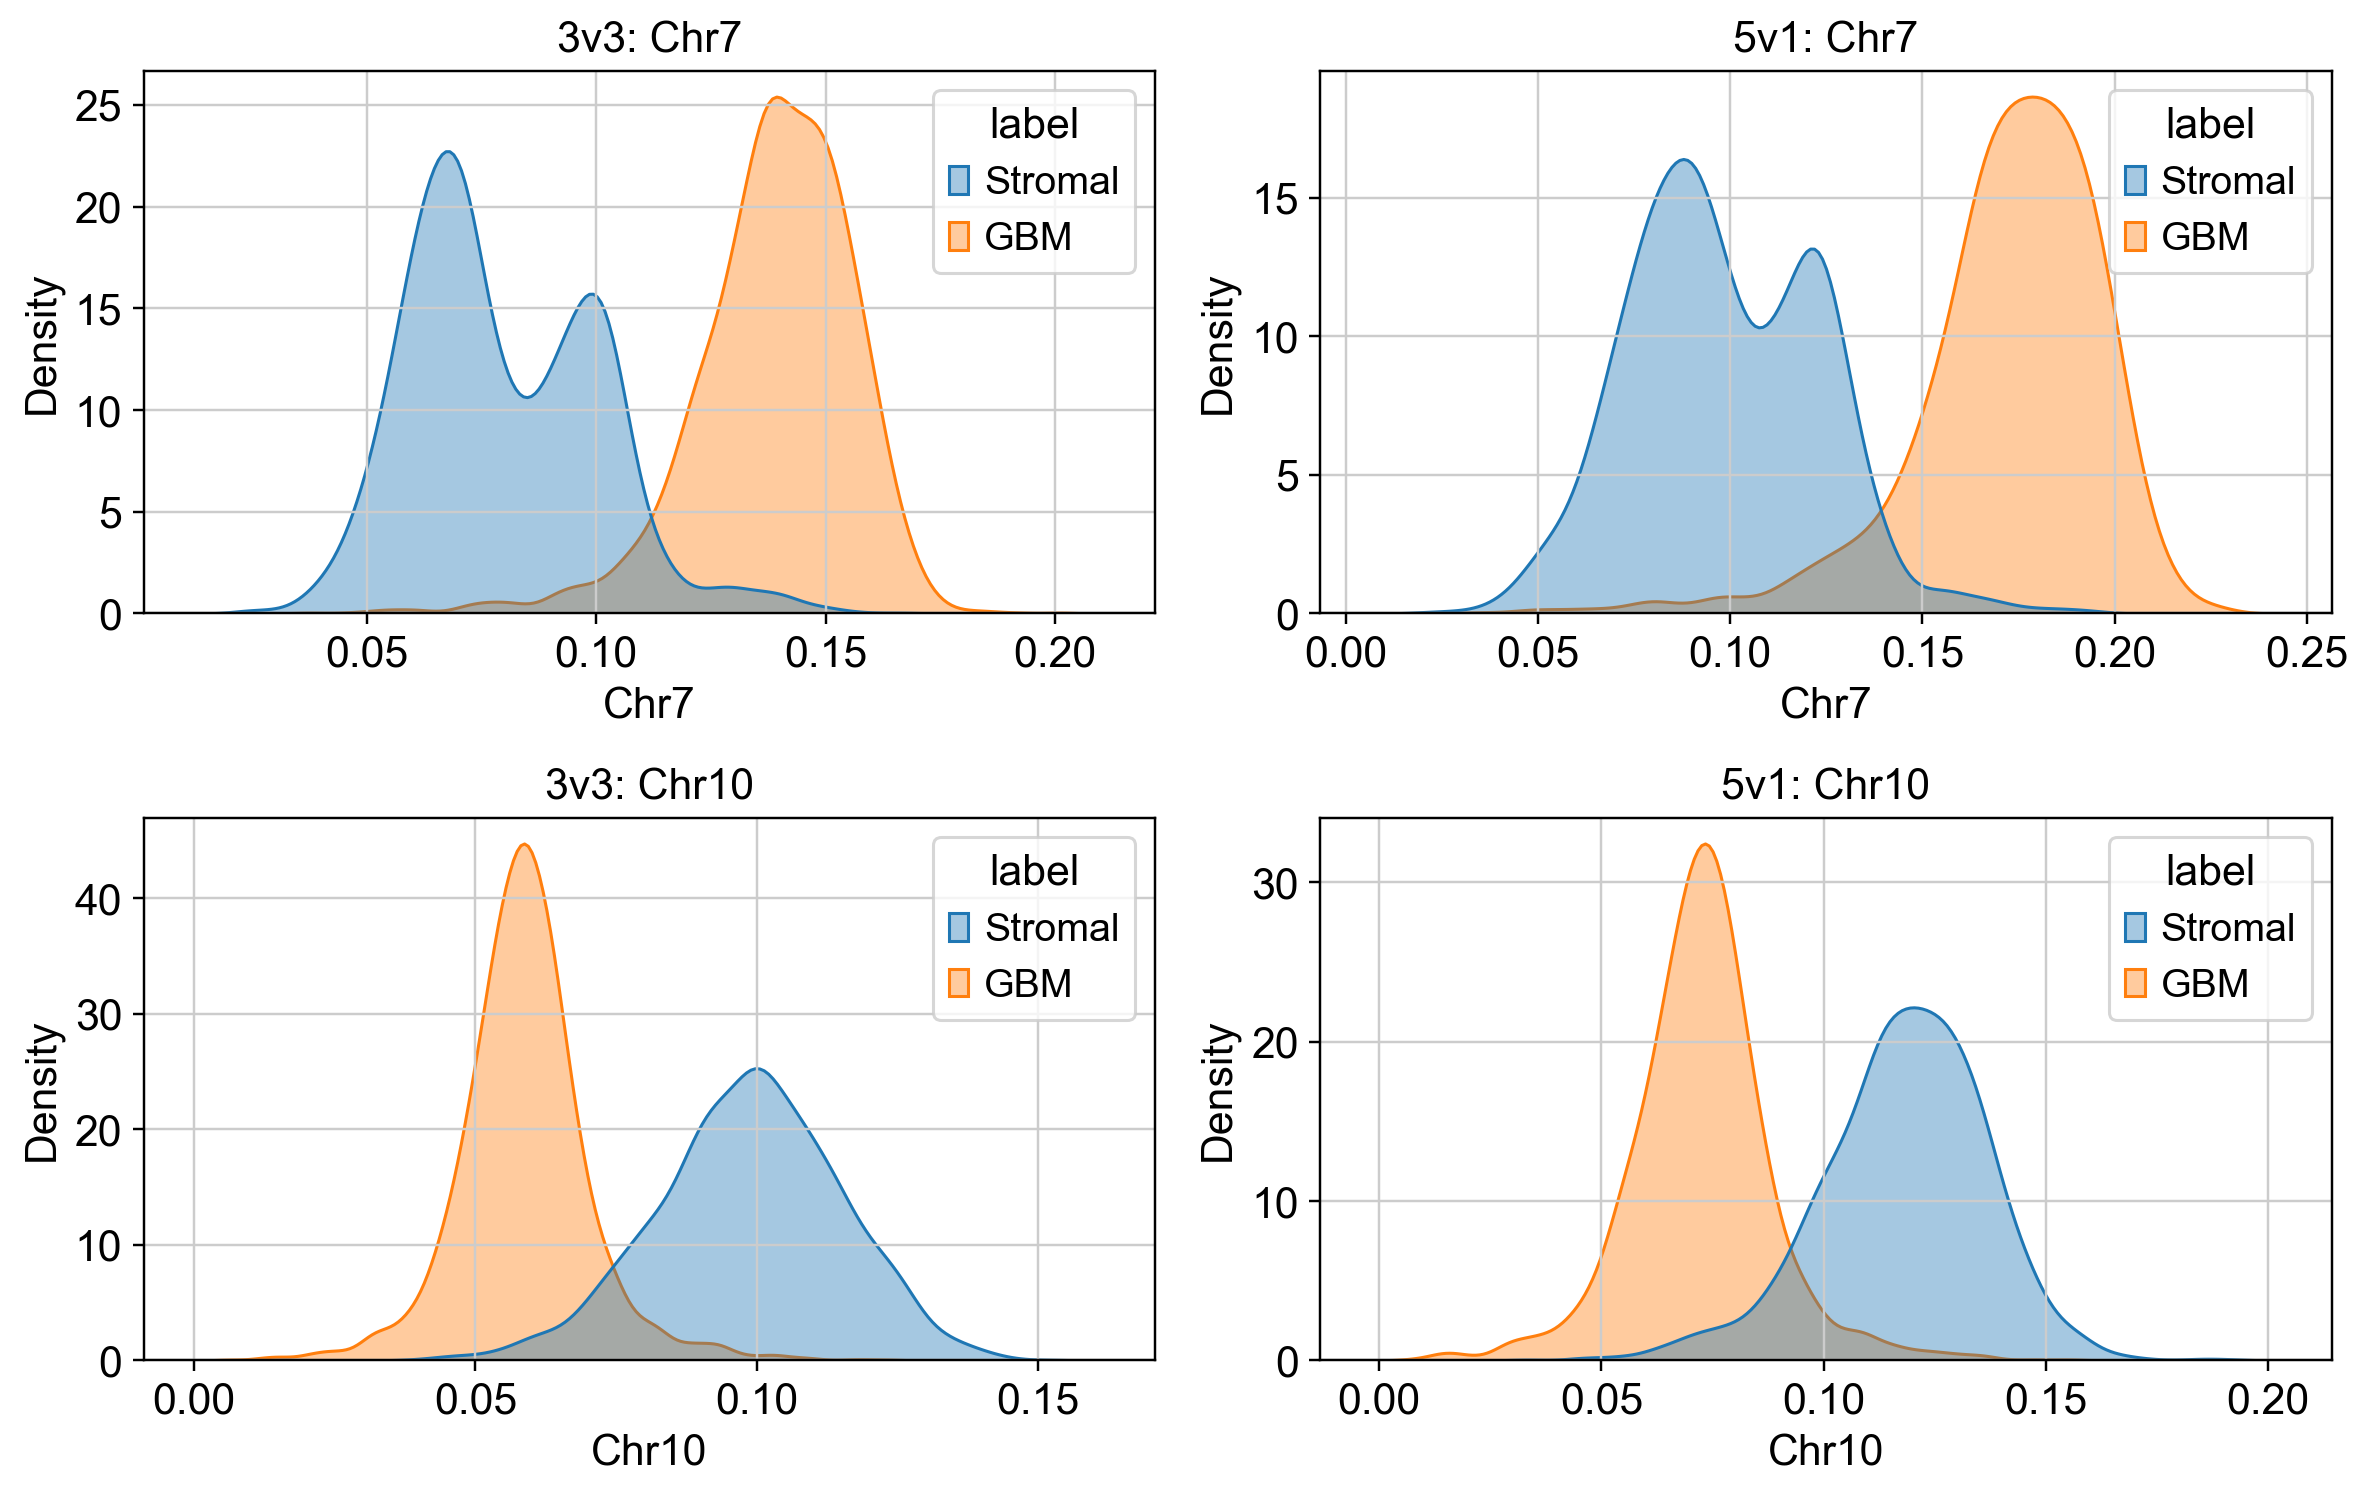

In [50]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
for col_i, name in enumerate(["3v3", "5v1"]):
    t = tables[name]
    for row_i, chrom in enumerate(["Chr7", "Chr10"]):
        ax = axes[row_i, col_i]
        sns.kdeplot(
            data=t,
            x=chrom,
            hue="label",
            hue_order=["Stromal", "GBM"],
            common_norm=False,
            fill=True,
            alpha=0.4,
            ax=ax,
        )
        ax.set_title(f"{name}: {chrom}")
plt.tight_layout()
plt.show()

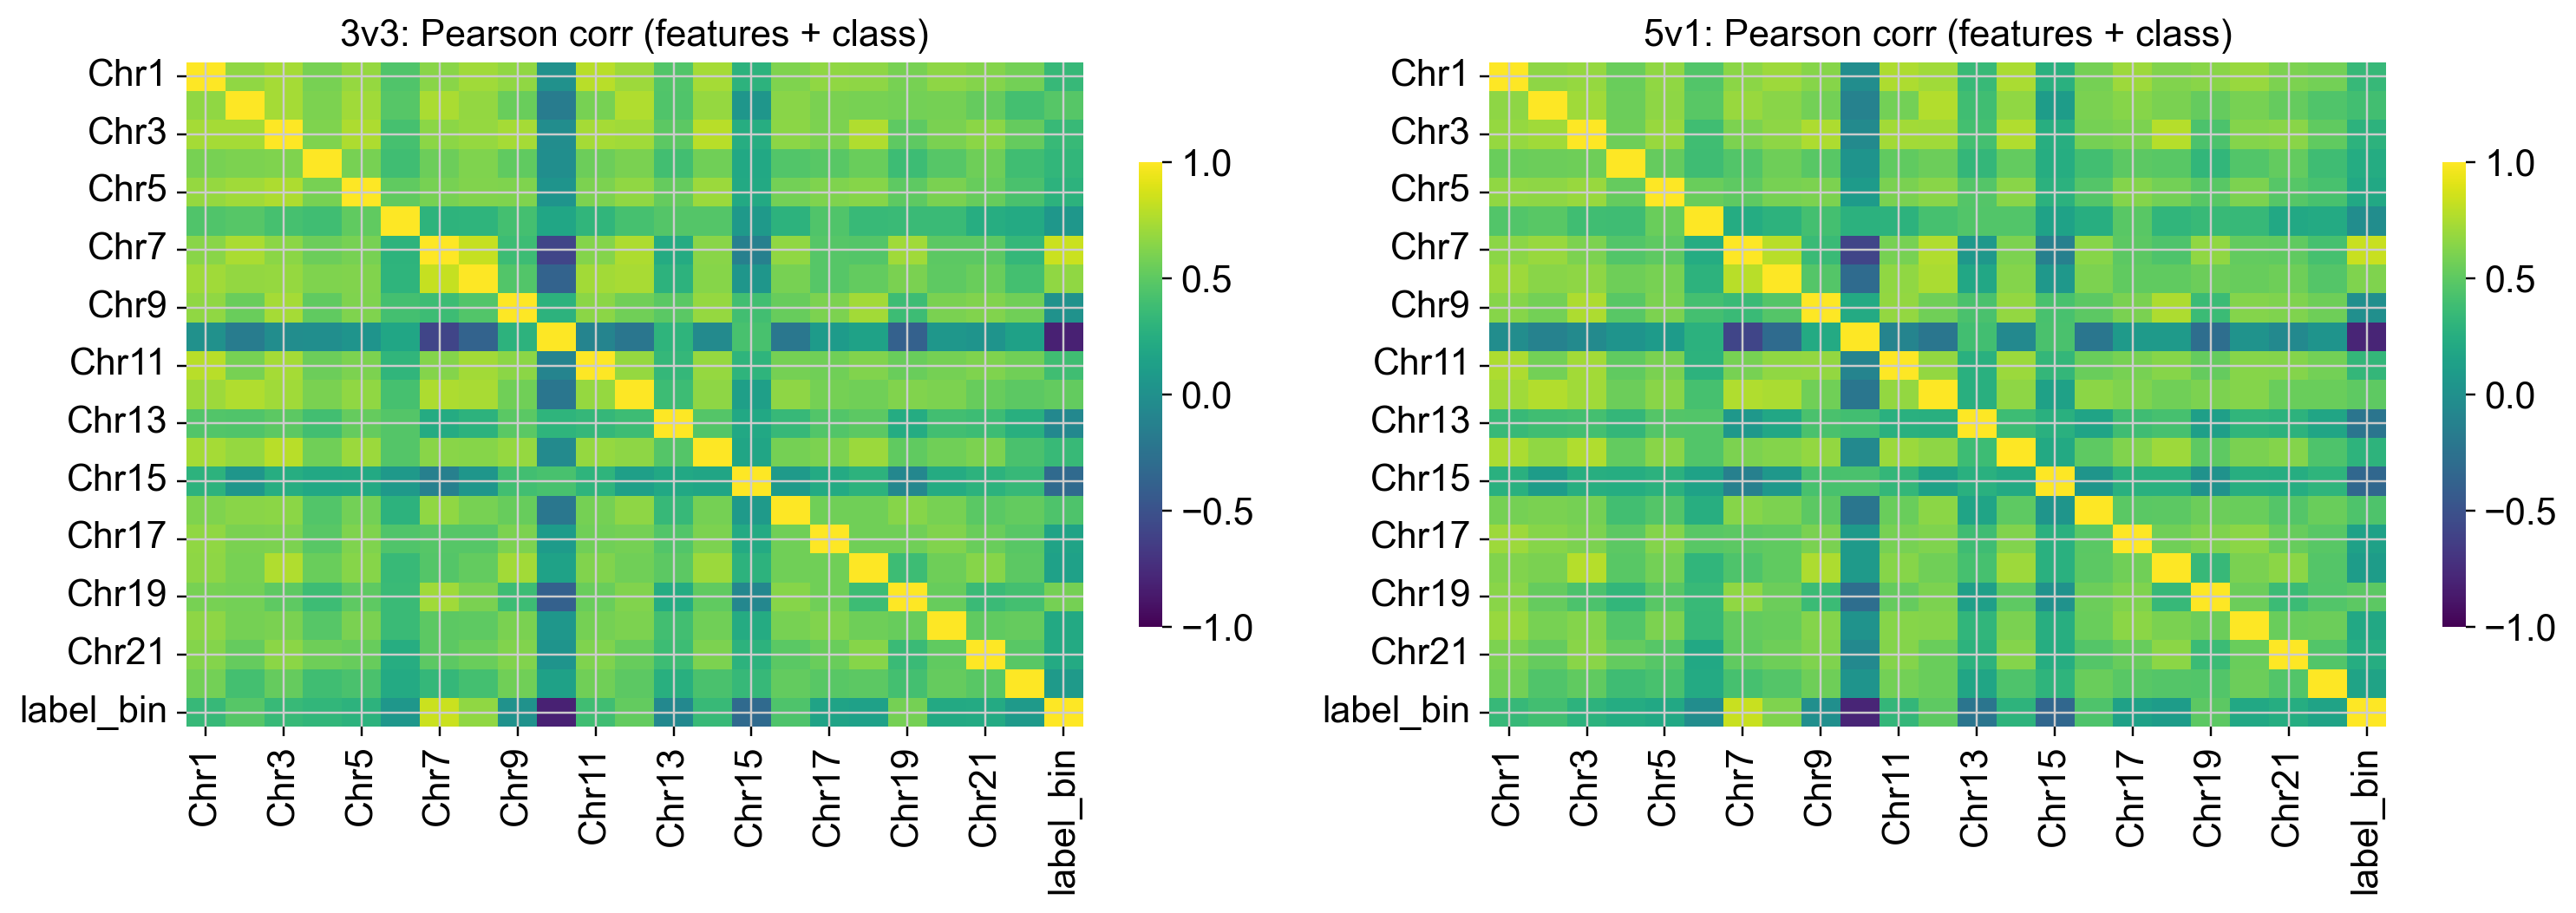

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, t) in zip(axes, tables.items()):
    num = t.assign(label_bin=(t["label"] == "GBM").astype(int))
    corr = num[CHR_COLS + ["label_bin"]].corr().loc[CHR_COLS + ["label_bin"], CHR_COLS + ["label_bin"]]
    sns.heatmap(
        corr,
        ax=ax,
        cmap="viridis",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(f"{name}: Pearson corr (features + class)")
plt.tight_layout()
plt.show()

## Градиентный бустинг: обучение на 3v3, тест на 5v1

Метки `GBM` / `Stromal` кодируем как `1 / 0`. Без подбора гиперпараметров

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

POS_CLASS = "GBM"

def split_xy(df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    X = df[CHR_COLS].astype(np.float32)
    y = (df["label"] == POS_CLASS).astype(int).values
    return X, y

X_train, y_train = split_xy(tables["3v3"])
X_test, y_test = split_xy(tables["5v1"])

print(f"train: {X_train.shape},  GBM={(y_train==1).sum()},  Stromal={(y_train==0).sum()}")
print(f"test : {X_test.shape},  GBM={(y_test==1).sum()},  Stromal={(y_test==0).sum()}")

model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

train: (5298, 22),  GBM=2688,  Stromal=2610
test : (3886, 22),  GBM=1842,  Stromal=2044


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Метрики на тесте 5v1

ROC-AUC, F1 (по положительному классу `GBM`), Accuracy, confusion matrix и сама
ROC-кривая

In [53]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "ROC-AUC":  roc_auc_score(y_test, y_proba),
    "F1 (GBM)": f1_score(y_test, y_pred, pos_label=1),
    "Accuracy": accuracy_score(y_test, y_pred),
}
for k, v in metrics.items():
    print(f"  {k:10s} = {v:.4f}")

print("\nclassification_report:")
print(classification_report(y_test, y_pred, target_names=["Stromal", "GBM"], digits=4))

print("confusion_matrix (rows = true, cols = pred):")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["true Stromal", "true GBM"], columns=["pred Stromal", "pred GBM"])
print(cm_df)

  ROC-AUC    = 0.9722
  F1 (GBM)   = 0.9135
  Accuracy   = 0.9156

classification_report:
              precision    recall  f1-score   support

     Stromal     0.9432    0.8933    0.9176      2044
         GBM     0.8882    0.9403    0.9135      1842

    accuracy                         0.9156      3886
   macro avg     0.9157    0.9168    0.9155      3886
weighted avg     0.9171    0.9156    0.9157      3886

confusion_matrix (rows = true, cols = pred):
              pred Stromal  pred GBM
true Stromal          1826       218
true GBM               110      1732


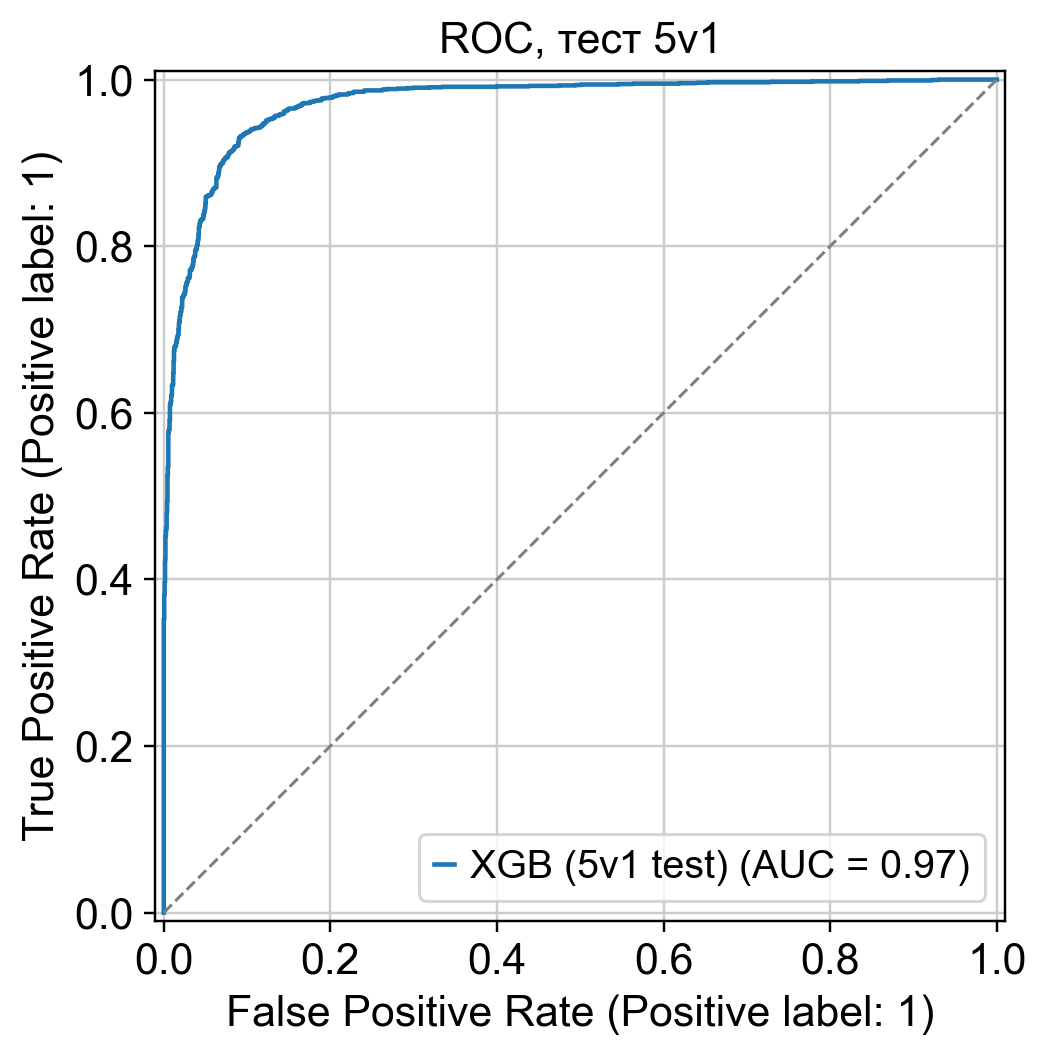

In [54]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name="XGB (5v1 test)", ax=ax)
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
ax.set_title("ROC, тест 5v1")
plt.tight_layout()
plt.show()

## SHAP values

Смотрим, на что классификатор опирается. Для бустинга используем
`shap.TreeExplainer` — он точный и быстрый. Считаем SHAP на тестовом наборе
(`5v1`), показываем три view: bar (глобальная важность), beeswarm (распределение
вкладов по клеткам)

In [55]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap_values.feature_names = CHR_COLS
print("shap_values shape:", shap_values.values.shape)

shap_values shape: (3886, 22)


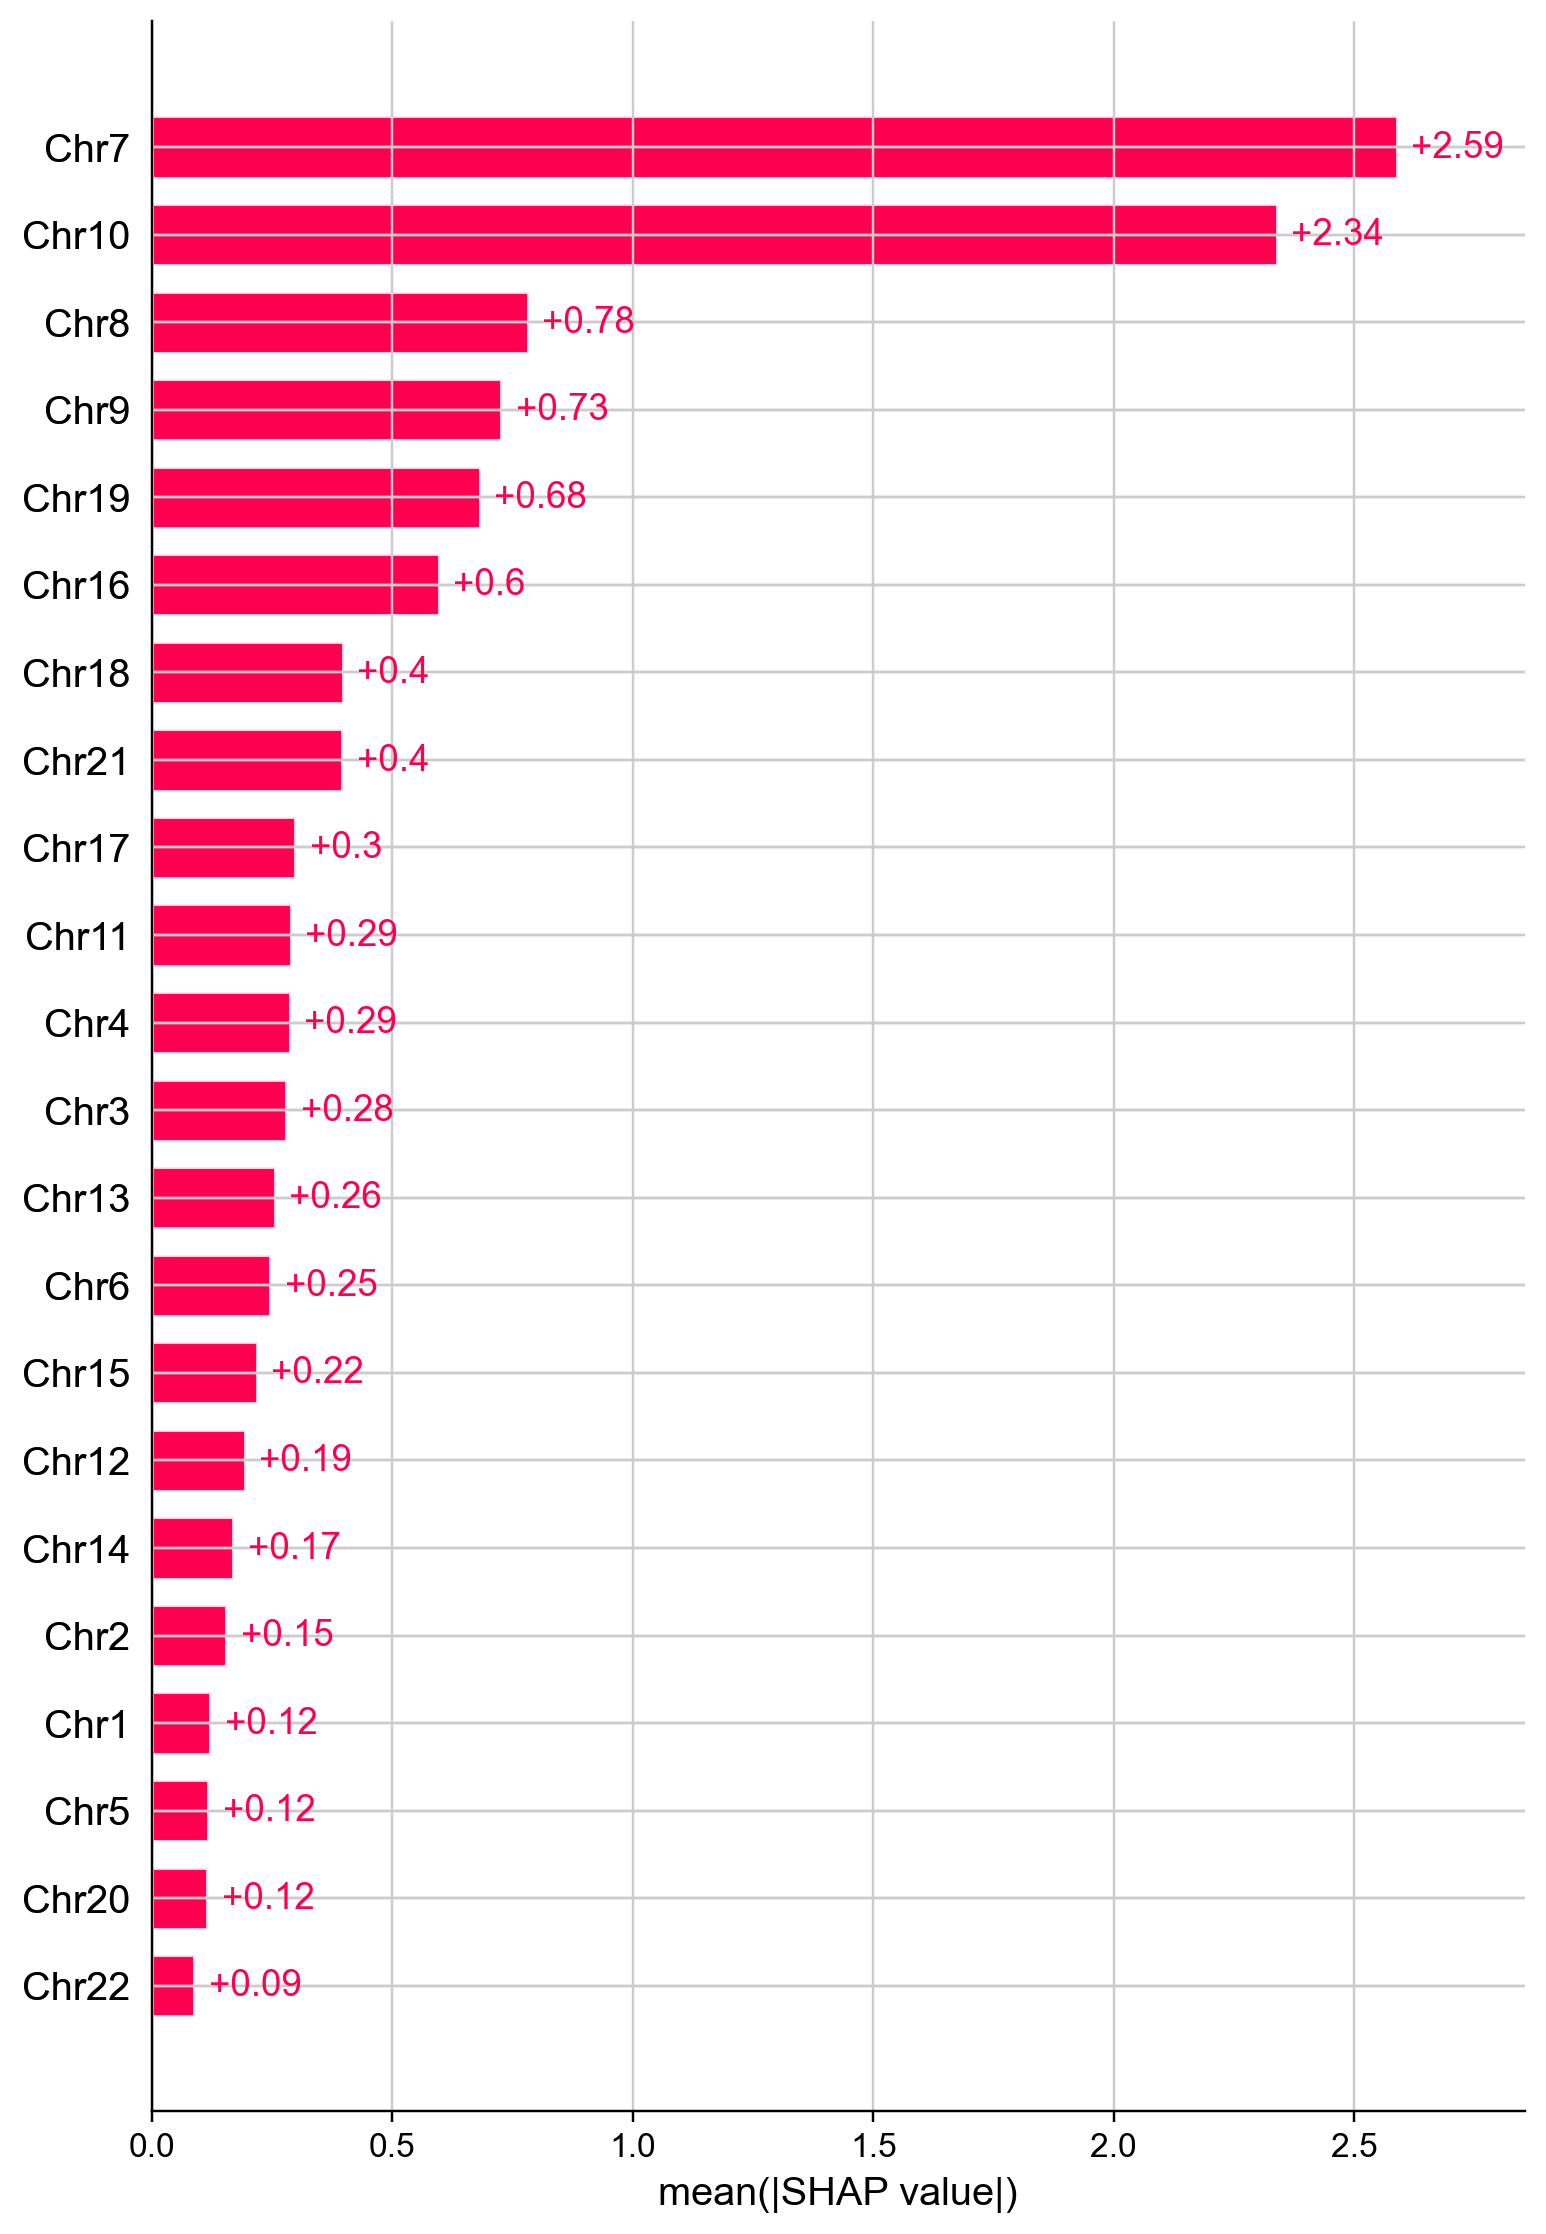

In [56]:
shap.plots.bar(shap_values, max_display=22, show=True)

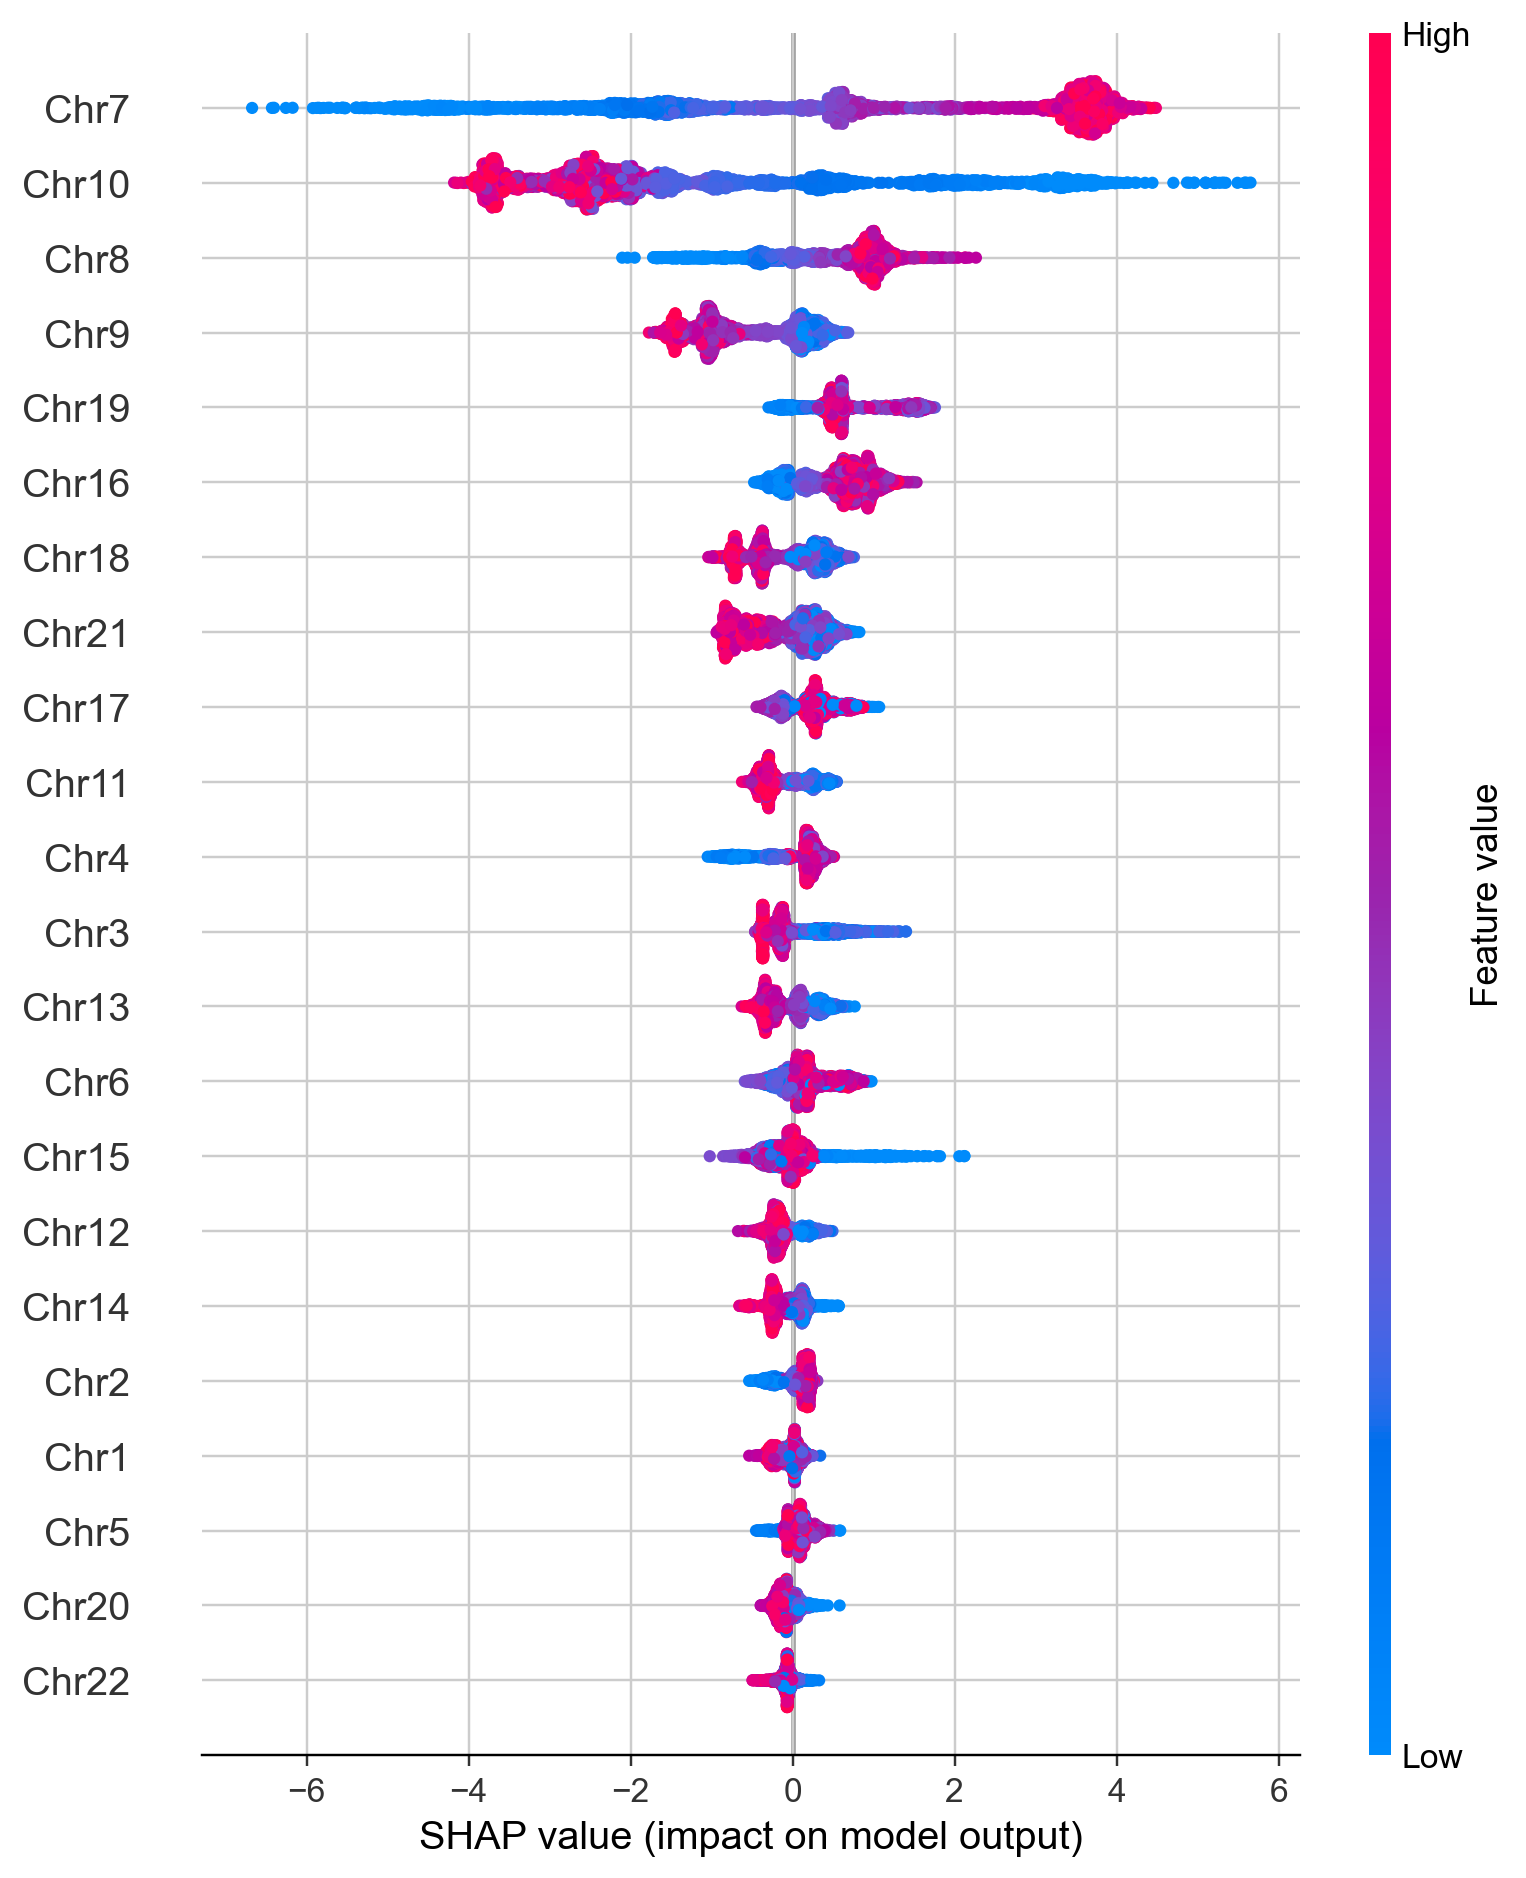

In [57]:
shap.plots.beeswarm(shap_values, max_display=22, show=True)

## UMAP теста 5v1: Leiden / ручная разметка / предсказание

Прогоняем обученный XGBoost на полном тесте, кладём ответы в `adata.obs['predicted']`
и рисуем три панели рядом. Категории для `leiden_named` и `predicted` фиксируем в
одном порядке `['Stromal', 'GBM']`, чтобы scanpy раскрасил их одинаково и панели
можно было сравнивать «по цвету».

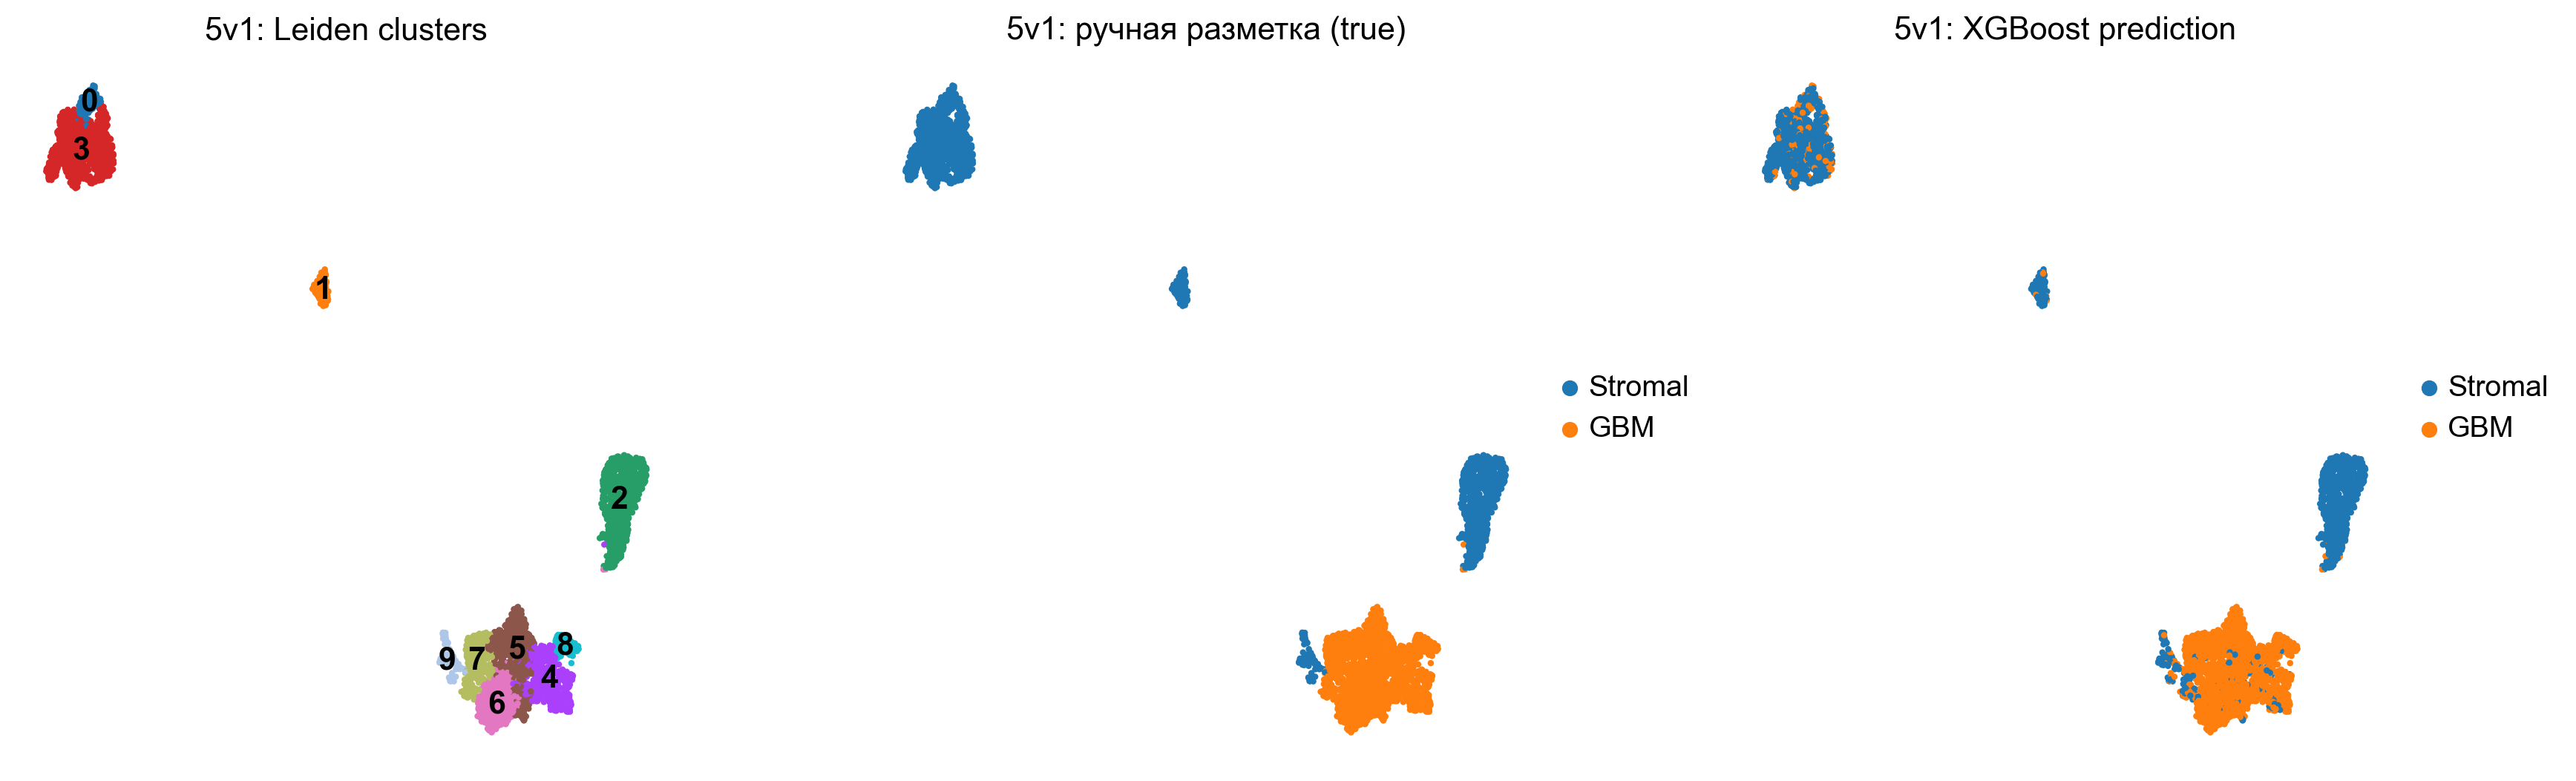

ошибок: 328 из 3886


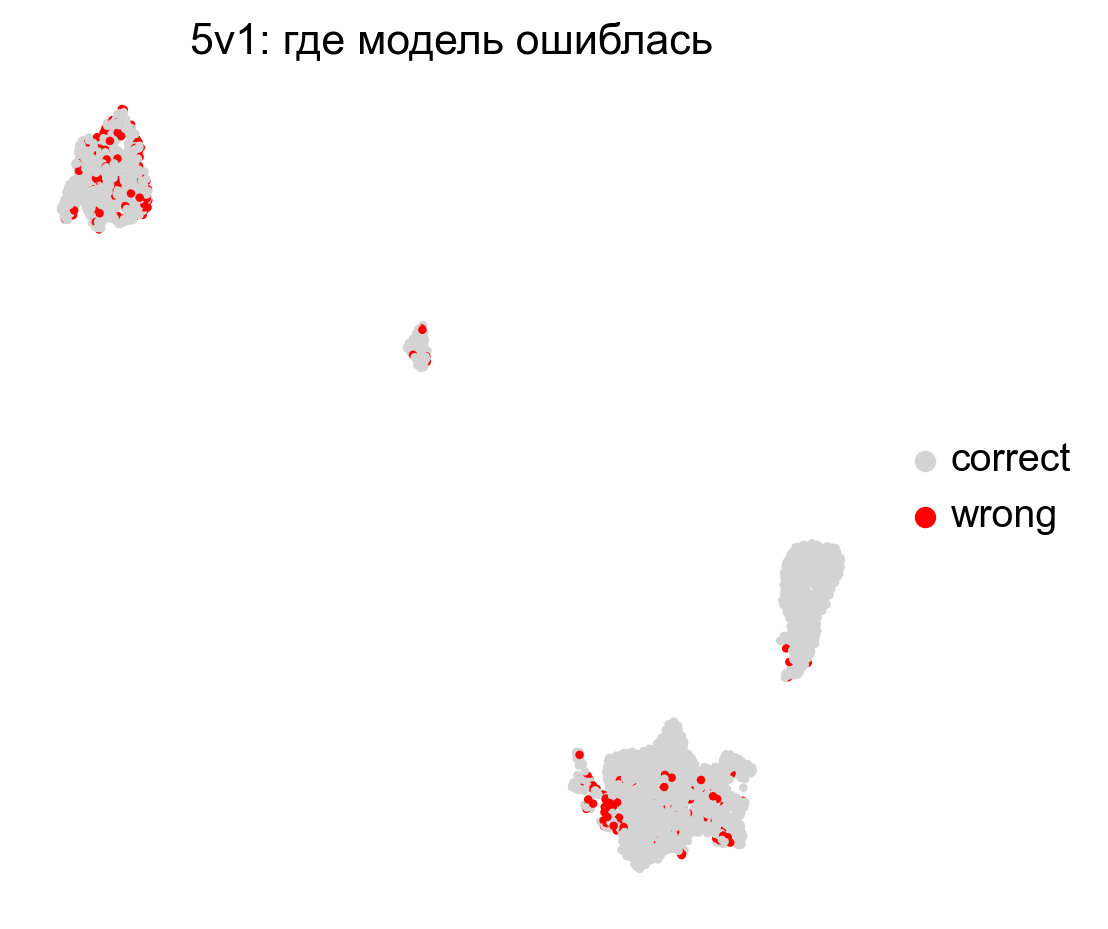

In [58]:
adata_test = adatas["5v1"]
test_df = tables["5v1"]

# Порядок клеток должен совпадать с тем, что внутри AnnData
assert list(test_df.index) == list(adata_test.obs_names)

proba_full = model.predict_proba(test_df[CHR_COLS].astype(np.float32))[:, 1]
pred_label = np.where(proba_full >= 0.5, "GBM", "Stromal")

CATS = ["Stromal", "GBM"]
adata_test.obs["predicted"] = pd.Categorical(pred_label, categories=CATS)
adata_test.obs["leiden_named"] = pd.Categorical(
    adata_test.obs["leiden_named"].astype(str), categories=CATS
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sc.pl.umap(adata_test, color="leiden", legend_loc="on data",
           title="5v1: Leiden clusters", ax=axes[0], show=False)
sc.pl.umap(adata_test, color="leiden_named",
           title="5v1: ручная разметка (true)", ax=axes[1], show=False)
sc.pl.umap(adata_test, color="predicted",
           title="5v1: XGBoost prediction", ax=axes[2], show=False)
plt.tight_layout()
plt.show()

# Сколько клеток модель перепутала и где они на UMAP
adata_test.obs["error"] = np.where(
    adata_test.obs["leiden_named"].astype(str) == adata_test.obs["predicted"].astype(str),
    "correct", "wrong",
)
adata_test.obs["error"] = pd.Categorical(adata_test.obs["error"], categories=["correct", "wrong"])
print("ошибок:", (adata_test.obs["error"] == "wrong").sum(),
      "из", adata_test.n_obs)
sc.pl.umap(adata_test, color="error", palette=["lightgray", "red"],
           title="5v1: где модель ошиблась")